# PACKAGE

In [1]:
from pathlib import Path
notebook_dir = Path().resolve()
data_path = notebook_dir.parent / "data" / "secom.csv"
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import datetime as dt
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Microsoft JhengHei'  # or 'Noto Sans TC'
plt.rcParams['axes.unicode_minus'] = False
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from scipy import stats as sps
from scipy.stats import gaussian_kde
from sklearn.base import clone
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, f1_score, r2_score, mean_absolute_error, mean_squared_error, balanced_accuracy_score, precision_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier


# Y LABELS

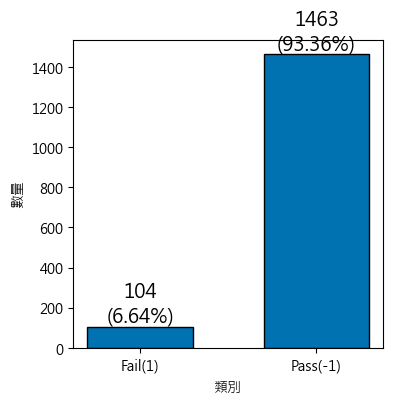

In [2]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].astype(int).replace({-1: 'Pass(-1)', 1: 'Fail(1)'})

# 固定顯示順序
order = ['Fail(1)', 'Pass(-1)']
y_counts = y.value_counts().reindex(order)

# 比例
y_ratio = y_counts / y_counts.sum()
x=[0, 0.5]
plt.figure(figsize=(4, 4))
bars = plt.bar(x, y_counts.values, color='#0072B2', edgecolor='k', width=0.3)

for bar, count, ratio in zip(bars, y_counts.values, y_ratio.values):
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        h,
        f'{count}\n({ratio:.2%})',
        ha='center',
        va='bottom',
        fontsize=14
    )
plt.xticks(x, order)
plt.xlabel("類別")
plt.ylabel("數量")
plt.show()

# X NA

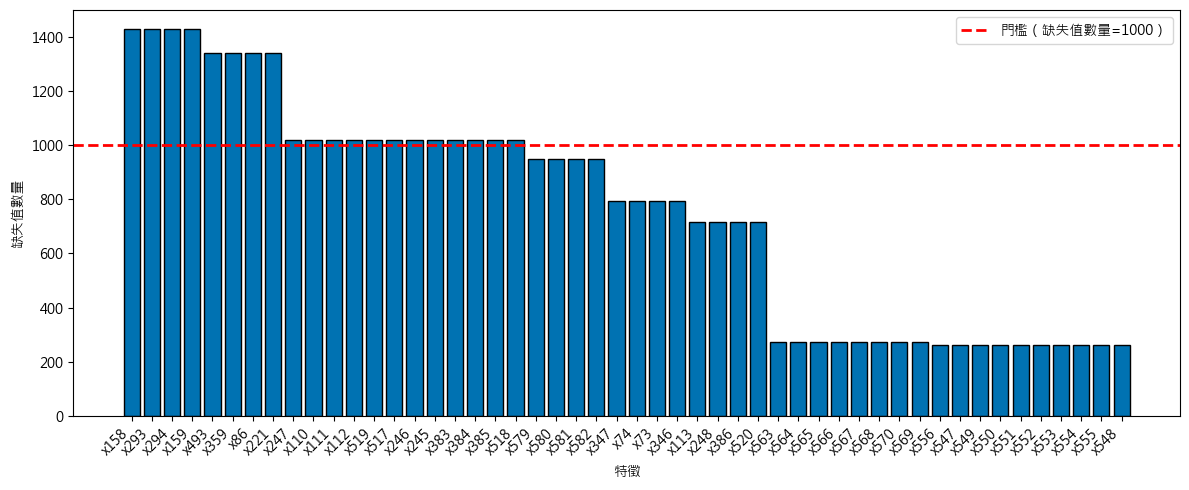

In [3]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1: 0, 1: 1}).astype(int)

na_cnt = X.isna().sum().sort_values(ascending=False)

topk = 50
na_top = na_cnt.head(topk)
x_ticks = na_top.index.tolist()

plt.figure(figsize=(12, 5))
plt.bar(range(len(na_top)), na_top.values, color='#0072B2', edgecolor = 'k')
plt.xticks(range(len(na_top)), x_ticks, rotation=45, ha='right')
plt.axhline(y=1000, color='r', linewidth=2, label='門檻（缺失值數量=1000）', linestyle='--')
plt.xlabel("特徵")
plt.ylabel("缺失值數量")
plt.legend()
plt.tight_layout()
plt.show()

# X DIFF

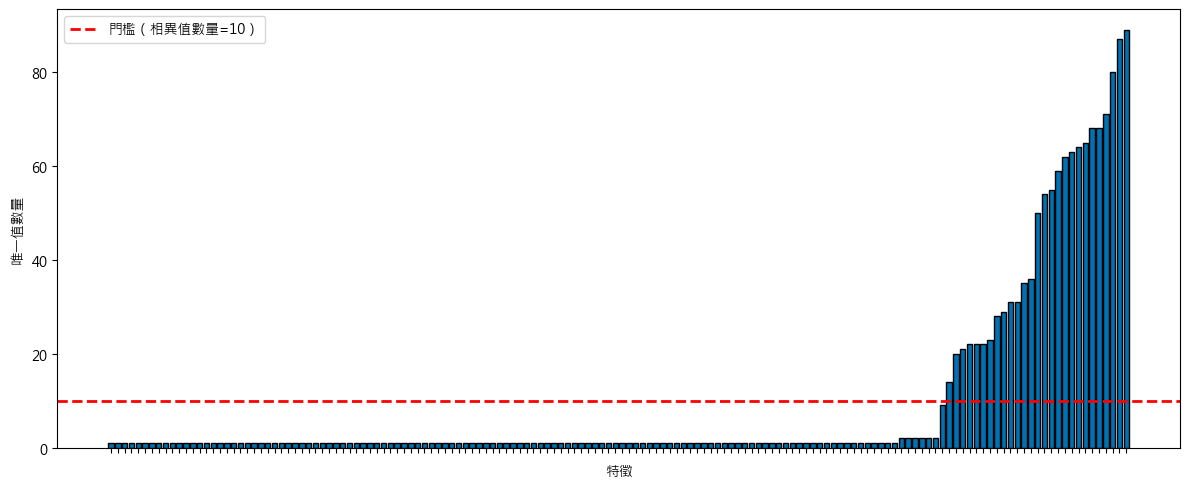

In [4]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()

uniq_counts = X.nunique(dropna=True).sort_values(ascending=True)

topk = 150
na_top = uniq_counts.head(topk)
x_ticks = na_top.index.tolist()

plt.figure(figsize=(12, 5))
plt.bar(range(len(na_top)), na_top.values, color='#0072B2', edgecolor = 'k')
plt.xticks(ticks=range(len(na_top)), labels=[''] * len(na_top))
plt.axhline(y=10, color='r', linewidth=2, label='門檻（相異值數量=10）', linestyle='--')

plt.xlabel("特徵")
plt.ylabel("唯一值數量")
plt.legend()
plt.tight_layout()
plt.show()

# X NA FEATURE NA

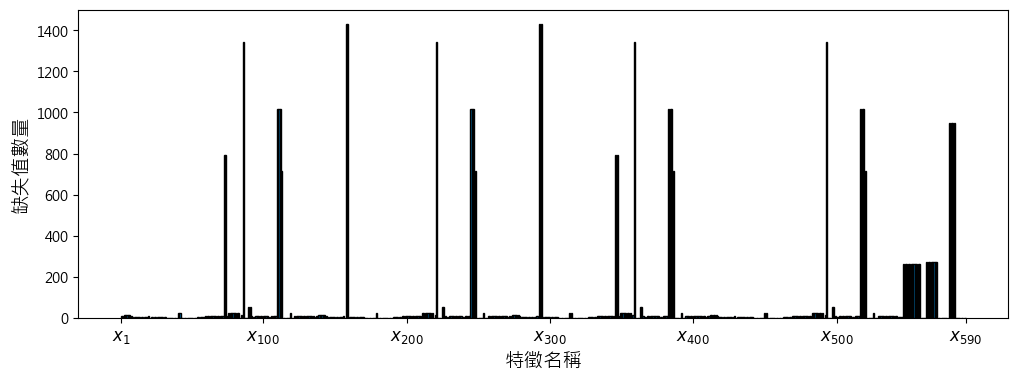

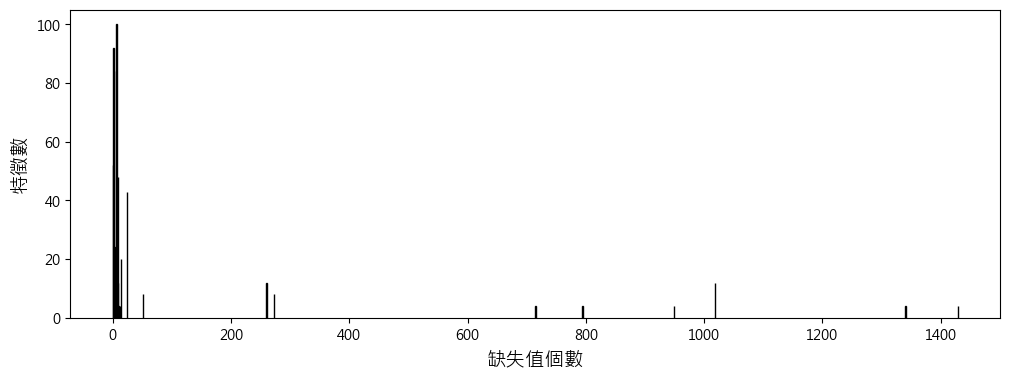

In [54]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])

# 1. 每個特徵的 NA 值數量
na_counts_feature = X.isna().sum()

tick_numbers = [1, 100, 200, 300, 400, 500, 590]

tick_positions = [i - 1 for i in tick_numbers]
tick_labels = [f"$x_{{{i}}}$" for i in tick_numbers]

plt.figure(figsize=(12, 4))
plt.bar(
    range(len(na_counts_feature)),
    na_counts_feature.values,
    color='#0072B2',
    edgecolor='k'
)

plt.xlabel("特徵名稱", fontsize=14)
plt.ylabel("缺失值數量", fontsize=14)

plt.xticks(
    ticks=tick_positions,
    labels=tick_labels,
    fontsize=12
)

plt.show()

# 統計「缺失值個數 = k」的特徵數
missing_count_dist_feature = (
    na_counts_feature
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12, 4))
plt.bar(
    missing_count_dist_feature.index,
    missing_count_dist_feature.values,
    color='#0072B2',
    edgecolor='k'
)

plt.xlabel("缺失值個數", fontsize=14)
plt.ylabel("特徵數", fontsize=14)
plt.show()

In [32]:
na_counts_sample

0        44
1        36
2        20
3        20
4        40
       ... 
1562     52
1563     52
1564    148
1565     60
1566    152
Length: 1567, dtype: int64

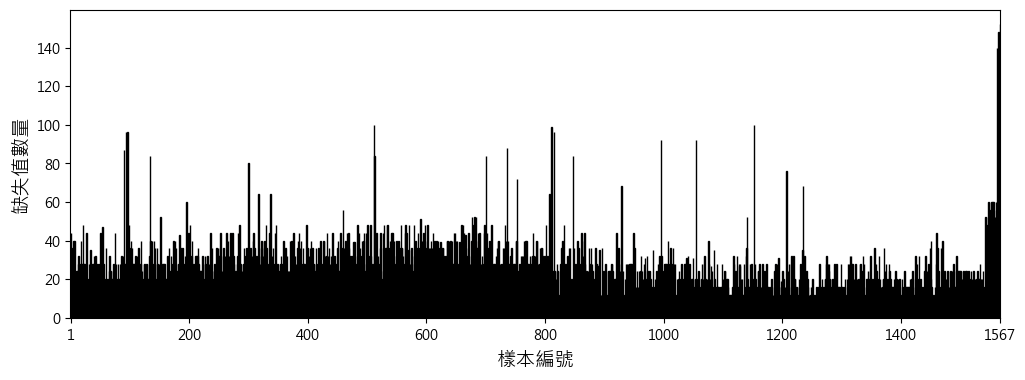

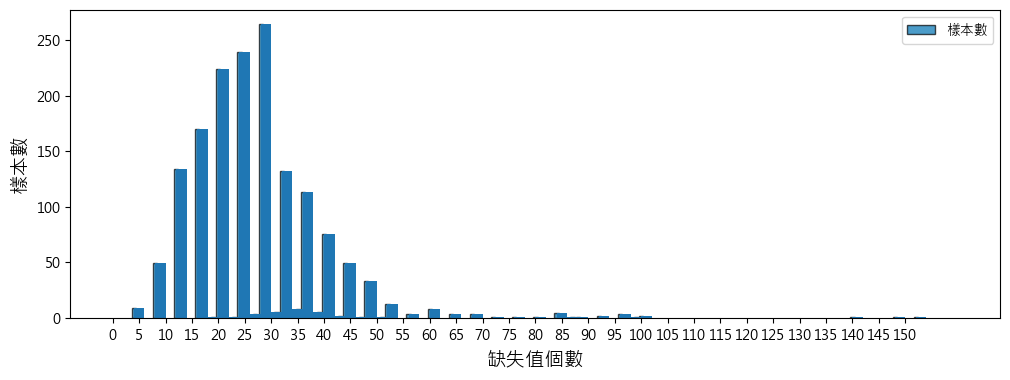

In [38]:
# 每個樣本的 NA 值數量
na_counts_sample = X.isna().sum(axis=1)

plt.figure(figsize=(12, 4))
plt.bar(
    range(len(na_counts_sample)),
    na_counts_sample.values,
    color='#0072B2',
    edgecolor='k'
)

plt.xlabel("樣本編號", fontsize=14)
plt.ylabel("缺失值數量", fontsize=14)

# 指定要顯示的樣本編號
tick_numbers = [1, 200, 400, 600, 800, 1000, 1200, 1400, len(na_counts_sample)]

# 轉成 matplotlib 實際位置
tick_positions = [i - 1 for i in tick_numbers]

plt.xticks(
    ticks=tick_positions,
    labels=tick_numbers,
    fontsize=10
)

plt.xlim(-1, len(na_counts_sample))

plt.show()

# 統計「缺失值個數 = k」的樣本數
missing_count_dist = (
    na_counts_sample
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12, 4))

# 長條圖
plt.bar(
    missing_count_dist.index,
    missing_count_dist.values,
    color='#0072B2',
    edgecolor='k',
    alpha=0.7,
    label='樣本數'
)

# # 曲線圖
# plt.plot(
#     missing_count_dist.index,
#     missing_count_dist.values,
#     marker='o',
#     linewidth=2,
#     label='分布曲線'
# )
plt.hist(na_counts_sample, bins=np.arange(0, x_max + 10, 2))
plt.xlabel("缺失值個數", fontsize=14)
plt.ylabel("樣本數", fontsize=14)

# x 軸每 10 個為單位
x_min = missing_count_dist.index.min()
x_max = missing_count_dist.index.max()

plt.xticks(
    ticks=range(0, x_max + 1, 5),
    fontsize=10
)

plt.legend()
plt.show()


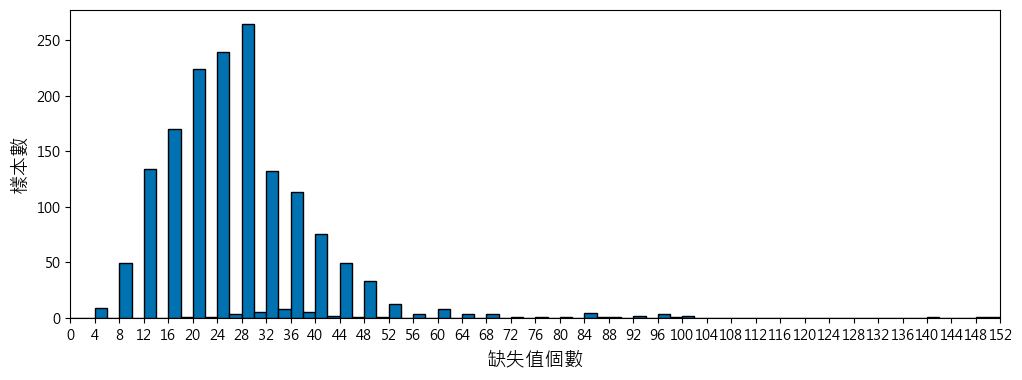

In [53]:
import numpy as np
import matplotlib.pyplot as plt

# 每個樣本的 NA 值數量
na_counts_sample = X.isna().sum(axis=1)

plt.figure(figsize=(12, 4))

bin_width = 2
x_min = 0
x_max = na_counts_sample.max()

# 建立 bin 邊界
bins = np.arange(x_min, x_max + bin_width, bin_width)

plt.hist(
    na_counts_sample,
    bins=bins,
    color='#0072B2',
    edgecolor='k'
)

plt.xlabel("缺失值個數", fontsize=14)
plt.ylabel("樣本數", fontsize=14)

plt.xticks(
    ticks=range(0, x_max + 4, 4),
    fontsize=10
)

plt.xlim(x_min, bins[-1])

plt.show()

In [19]:
X.shape

(1567, 590)

In [21]:
uniq_counts = X.nunique(dropna=False)
X.loc[:, uniq_counts >= 10]

,x1,x2,x3,x4,x5,x7,x8,x9,x10,x11,...,x581,x582,x583,x584,x585,x586,x587,x588,x589,x590
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,97.6133,0.1242,1.5005,0.0162,-0.0034,...,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,102.3433,0.1247,1.4966,-0.0005,-0.0148,...,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,95.4878,0.1241,1.4436,0.0041,0.0013,...,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,2988.72,2479.90,2199.0333,909.7926,1.3204,104.2367,0.1217,1.4882,-0.0124,-0.0033,...,0.0044,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.3967,0.1235,1.5031,-0.0031,-0.0072,...,NaN,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1562,2899.41,2464.36,2179.7333,3085.3781,1.4843,82.2467,0.1248,1.3424,-0.0045,-0.0057,...,0.0047,203.1720,0.4988,0.0143,0.0039,2.8669,0.0068,0.0138,0.0047,203.1720
1563,3052.31,2522.55,2198.5667,1124.6595,0.8763,98.4689,0.1205,1.4333,-0.0061,-0.0093,...,NaN,NaN,0.4975,0.0131,0.0036,2.6238,0.0068,0.0138,0.0047,203.1720
1564,2978.81,2379.78,2206.3000,1110.4967,0.8236,99.4122,0.1208,NaN,NaN,NaN,...,0.0025,43.5231,0.4987,0.0153,0.0041,3.0590,0.0197,0.0086,0.0025,43.5231
1565,2894.92,2532.01,2177.0333,1183.7287,1.5726,98.7978,0.1213,1.4622,-0.0072,0.0032,...,0.0075,93.4941,0.5004,0.0178,0.0038,3.5662,0.0262,0.0245,0.0075,93.4941


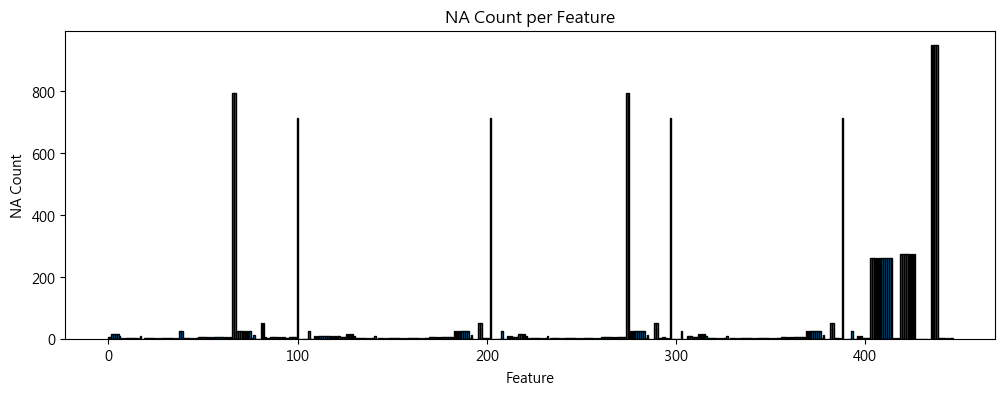

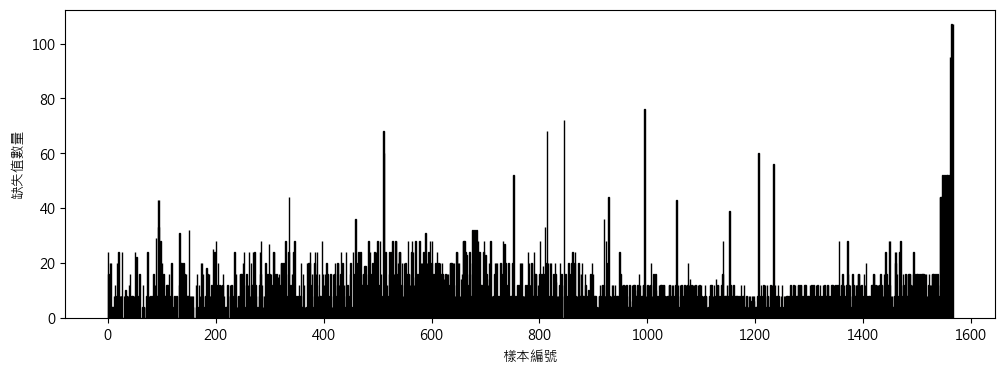

In [9]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

# 1. 每個特徵的 NA 值數量
na_counts_feature = X.isna().sum()

plt.figure(figsize=(12, 4))
plt.bar(range(len(na_counts_feature)), na_counts_feature.values, color='#0072B2', edgecolor = 'k')
plt.xlabel("Feature")
plt.ylabel("NA Count")
plt.title("NA Count per Feature")
plt.show()

# 2. 每個樣本的 NA 值數量
na_counts_sample = X.isna().sum(axis=1)

plt.figure(figsize=(12, 4))
plt.bar(range(len(na_counts_sample)), na_counts_sample.values, color='#0072B2', edgecolor = 'k')
plt.xlabel("樣本編號")
plt.ylabel("缺失值數量")
plt.show()

# PCA

In [ ]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
# y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

# na_counts = X.isna().sum()
# X = X.loc[:, na_counts <= 1000].copy()
# uniq_counts = X.nunique(dropna=False)
# X = X.loc[:, uniq_counts >= 10].copy()
X.isna().sum().sum()

41951

41951
17804

PCA 保留 131 個主成分


C:\Users\No\AppData\Local\Temp\ipykernel_11188\4003866695.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


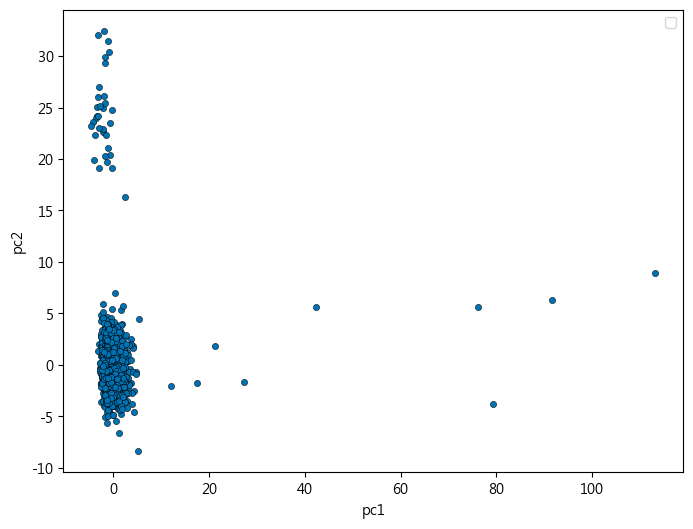

   主成分      解釋比例    累積解釋比例
0  PC1  0.056426  0.056426
1  PC2  0.038645  0.095071


In [3]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

plt.figure(figsize=(8,6))
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', s=20, color='#0072B2', edgecolor = 'k')
plt.legend()
plt.show()

# 前兩個主成分的解釋比例與累積比例
explained_ratio = pca.explained_variance_ratio_
cumulative_ratio = np.cumsum(explained_ratio)
pca_ratio_df = pd.DataFrame({'主成分': ['PC1', 'PC2'], '解釋比例': explained_ratio[:2], '累積解釋比例': cumulative_ratio[:2]})

print(pca_ratio_df)


PC1 解釋變異量：0.0564
PC2 解釋變異量：0.0386
前兩個主成分累積解釋變異量：0.0951
前兩個主成分累積解釋變異量百分比：9.51%
PCA 保留 131 個主成分


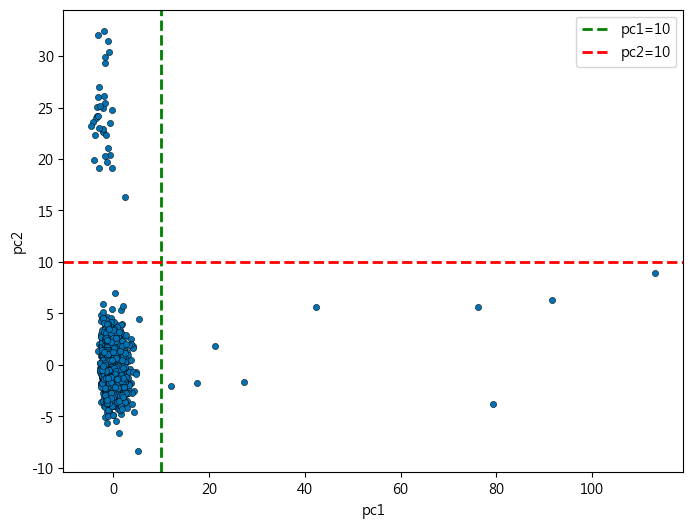

In [16]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
pc1_var = pca.explained_variance_ratio_[0]
pc2_var = pca.explained_variance_ratio_[1]
pc12_cum_var = pca.explained_variance_ratio_[:2].sum()

print(f"PC1 解釋變異量：{pc1_var:.4f}")
print(f"PC2 解釋變異量：{pc2_var:.4f}")
print(f"前兩個主成分累積解釋變異量：{pc12_cum_var:.4f}")
print(f"前兩個主成分累積解釋變異量百分比：{pc12_cum_var*100:.2f}%")
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

plt.figure(figsize=(8,6))
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', s=20, color='#0072B2', edgecolor = 'k')
# 門檻線
plt.axvline(10, linestyle='--', color='g', linewidth=2, label='pc1=10')
plt.axhline(10, linestyle='--', color='r', linewidth=2, label='pc2=10')
plt.legend()
plt.show()

PCA 保留 131 個主成分
cluster sizes: {0: 1563, 1: 4}
cluster     0  1
y               
0        1460  3
1         103  1


c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


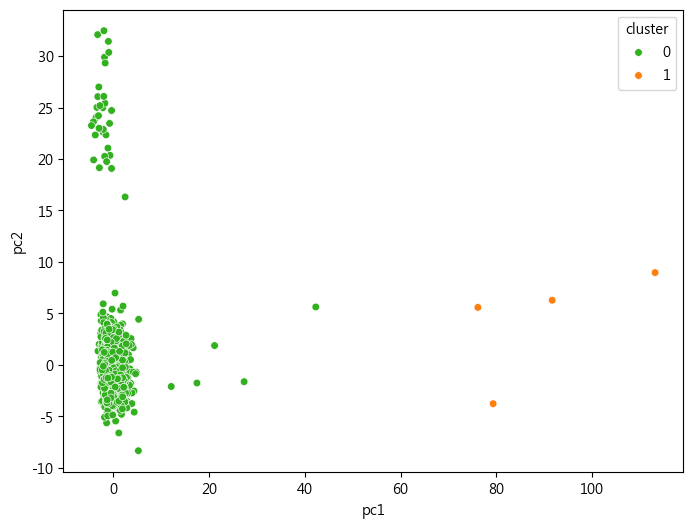

In [ ]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
labels = kmeans.fit_predict(X_pca)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

X_pca_df['cluster'] = labels

plt.figure(figsize=(8,6))
palette = {
    0: "#33B020",  # cluster 0, y=1
    1: '#ff7f0e',  # cluster 1, y=0
}
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', hue='cluster', s=20, palette=palette)
plt.show()

In [10]:
X_std

,x1,x2,x3,x4,x5,x7,x8,x9,x10,x11,...,x581,x582,x583,x584,x585,x586,x587,x588,x589,x590
0,0.216411,0.856549,-0.434551,0.023500,-0.051987,-0.546749,0.256173,0.521406,1.121315,-0.372980,...,-0.349291,-0.220985,0.120331,-0.202448,-0.091826,-0.194761,-0.278654,-0.140893,-0.050083,0.201450
1,1.094037,-0.374751,1.020782,0.142049,-0.061313,0.209791,0.307169,0.468613,0.014491,-1.603007,...,0.288903,2.006795,0.532455,0.401942,0.439739,0.380511,-0.960619,0.421933,0.258167,1.167895
2,-1.114171,0.805982,-0.479627,0.670902,-0.049351,-0.886712,0.245974,-0.248829,0.319365,0.134136,...,4.526034,-0.164680,-1.263228,0.022039,0.014487,0.029495,2.972233,3.631596,3.316370,-0.171694
3,-0.354825,-0.190915,-0.049316,-1.107818,-0.052686,0.512631,0.001194,0.354905,-0.774204,-0.362190,...,-0.481485,-0.320891,-0.321230,-0.288790,-0.357609,-0.280042,-0.106352,-0.167828,-0.297870,-0.268061
4,0.234139,0.095176,1.121165,-0.167425,-0.048944,-0.101558,0.184779,0.556601,-0.157829,-0.782989,...,0.094126,0.424783,-5.914343,26.551870,26.752218,26.594405,-0.106352,-0.167828,-0.297870,-0.268061
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1520,-1.563472,-0.384465,-0.707284,3.801642,-0.049806,-3.004559,0.317368,-1.618736,-0.250616,-0.621144,...,-0.337037,1.919611,-0.380105,-0.058546,0.014487,-0.055510,-1.186275,-0.292585,-0.193613,1.114111
1521,0.505750,0.340290,-0.065223,-0.622946,-0.060489,-0.409900,-0.121197,-0.388256,-0.356659,-1.009573,...,0.428640,0.356134,-0.762792,-0.127619,-0.065248,-0.122690,-1.186275,-0.292585,-0.193613,1.114111
1522,-0.488938,-1.437908,0.198417,-0.654906,-0.061415,-0.259024,-0.090599,0.295257,-0.215528,-0.411018,...,-1.396320,-0.846159,-0.409543,-0.000985,0.067643,-0.002423,-0.146648,-0.882347,-0.958164,-0.592100
1523,-1.624236,0.458114,-0.799332,-0.489650,-0.048255,-0.357294,-0.039603,0.002953,-0.429564,0.339141,...,1.011141,0.019543,0.090894,0.142917,-0.012091,0.137740,0.377195,0.920962,0.779451,-0.058046


PC1 解釋變異量：0.0365
PC2 解釋變異量：0.0284
前兩個主成分累積解釋變異量：0.0649
前兩個主成分累積解釋變異量百分比：6.49%
PCA 保留 137 個主成分


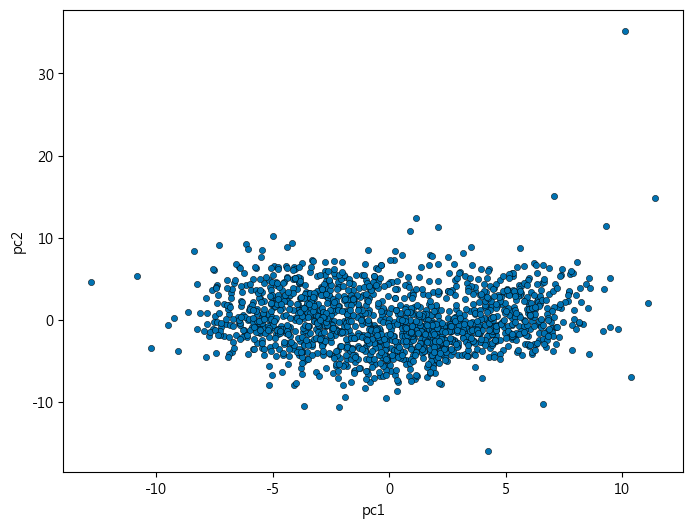

   主成分      解釋比例    累積解釋比例
0  PC1  0.036493  0.036493
1  PC2  0.028448  0.064942


In [6]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
pc1_var = pca.explained_variance_ratio_[0]
pc2_var = pca.explained_variance_ratio_[1]
pc12_cum_var = pca.explained_variance_ratio_[:2].sum()

print(f"PC1 解釋變異量：{pc1_var:.4f}")
print(f"PC2 解釋變異量：{pc2_var:.4f}")
print(f"前兩個主成分累積解釋變異量：{pc12_cum_var:.4f}")
print(f"前兩個主成分累積解釋變異量百分比：{pc12_cum_var*100:.2f}%")
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

plt.figure(figsize=(8,6))
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', s=20, color='#0072B2', edgecolor = 'k')
plt.show()

# 前兩個主成分的解釋比例與累積比例
explained_ratio = pca.explained_variance_ratio_
cumulative_ratio = np.cumsum(explained_ratio)
pca_ratio_df = pd.DataFrame({'主成分': ['PC1', 'PC2'], '解釋比例': explained_ratio[:2], '累積解釋比例': cumulative_ratio[:2]})

print(pca_ratio_df)

PCA 保留 137 個主成分
cluster sizes: {0: 718, 1: 807}
cluster    0    1
y                
0        660  770
1         58   37


c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


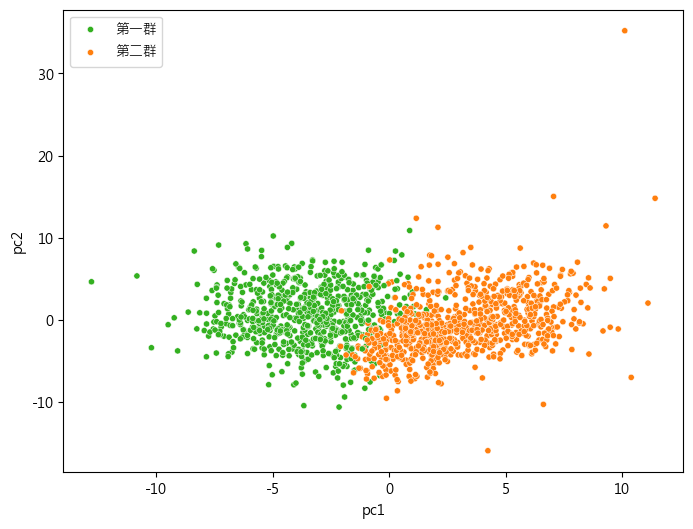

In [14]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
labels = kmeans.fit_predict(X_pca)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

X_pca_df['cluster'] = labels
X_pca_df['cluster'] = X_pca_df['cluster'].replace({1:'第二群', 0:'第一群'})

plt.figure(figsize=(8,6))
palette = {
    '第一群': "#33B020",  # cluster 0
    '第二群': '#ff7f0e',  # cluster 1
}
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', hue='cluster', s=20, palette=palette)
plt.legend(loc='best')
plt.show()

PCA 保留 137 個主成分
cluster sizes: {0: 718, 1: 807}
cluster    0    1
y                
0        660  770
1         58   37


c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


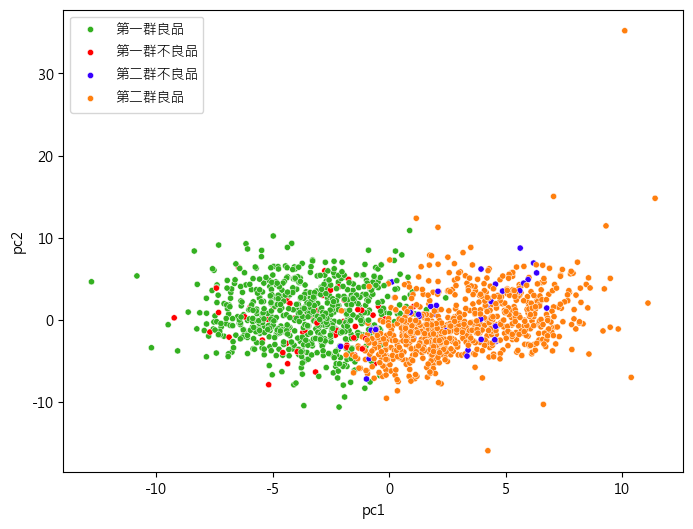

In [16]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
labels = kmeans.fit_predict(X_pca)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

X_pca_df['cluster'] = labels

X_pca_df['y'] = y.values

# 建立群別名稱
X_pca_df['cluster_name'] = X_pca_df['cluster'].map({
    0: '第一群',
    1: '第二群'
})
# 建立 4 類別欄位：(cluster, y)
X_pca_df['group'] = (
    X_pca_df['cluster_name'] +
    X_pca_df['y'].map({0: '良品', 1: '不良品'})
)
plt.figure(figsize=(8,6))
# 自訂 4 種顏色（可自行調整）
palette = {
    '第一群良品': "#33B020",
    '第一群不良品': "#ff0000",
    '第二群良品': '#ff7f0e',
    '第二群不良品': "#3700ff",
}

sns.scatterplot(
    data=X_pca_df,
    x=X_pca_df['pc1'], y='pc2',
    hue='group',
    palette=palette,
    s=20
)
plt.legend(loc='best')
plt.show()

PC1 解釋變異量：0.0405
PC2 解釋變異量：0.0336
前兩個主成分累積解釋變異量：0.0740
前兩個主成分累積解釋變異量百分比：7.40%
PCA 保留 125 個主成分


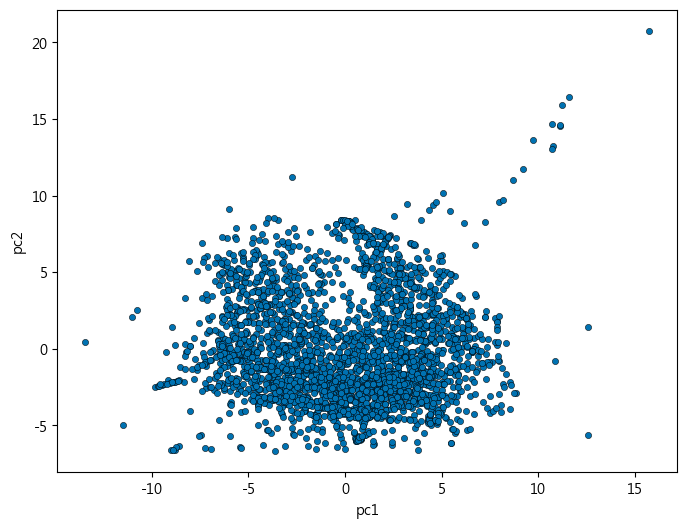

In [29]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=1, k_neighbors=5)
X_smote, y_smote = smote.fit_resample(X_std, y)
X_smote_df = pd.DataFrame(X_smote, columns=X_std.columns)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_smote_df)
pc1_var = pca.explained_variance_ratio_[0]
pc2_var = pca.explained_variance_ratio_[1]
pc12_cum_var = pca.explained_variance_ratio_[:2].sum()

print(f"PC1 解釋變異量：{pc1_var:.4f}")
print(f"PC2 解釋變異量：{pc2_var:.4f}")
print(f"前兩個主成分累積解釋變異量：{pc12_cum_var:.4f}")
print(f"前兩個主成分累積解釋變異量百分比：{pc12_cum_var*100:.2f}%")

print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

plt.figure(figsize=(8,6))
sns.scatterplot(data=X_pca_df, x=X_pca_df['pc1'], y=X_pca_df['pc2'], s=20, color='#0072B2', edgecolor = 'k')
plt.show()



PCA 保留 125 個主成分
cluster sizes: {0: 1548, 1: 1312}
cluster    0    1
y                
0        619  811
1        929  501


c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=12.
  warnings.warn(


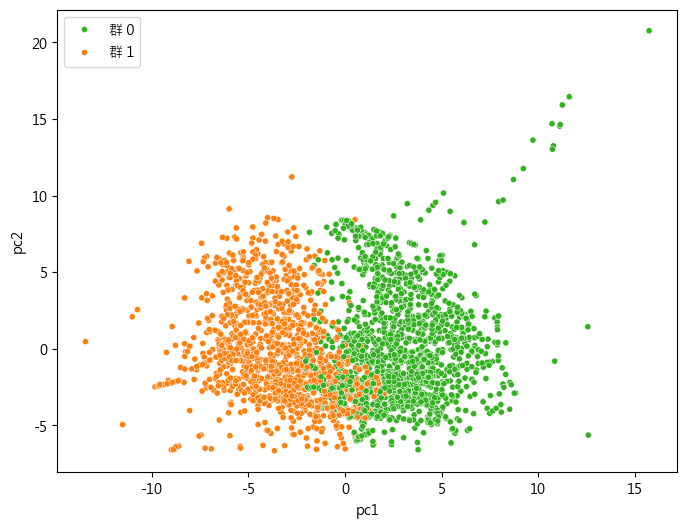

In [37]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=1, k_neighbors=5)
X_smote, y_smote = smote.fit_resample(X_std, y)
X_smote_df = pd.DataFrame(X_smote, columns=X_std.columns)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_smote_df)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
labels = kmeans.fit_predict(X_pca)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y_smote.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

X_pca_df['cluster'] = labels
X_pca_df['cluster'] = X_pca_df['cluster'].replace({1:'群 1', 0:'群 0'})

plt.figure(figsize=(8,6))
palette = {
    '群 0': "#33B020",  # cluster 1
    '群 1': '#ff7f0e',  # cluster 0
}
sns.scatterplot(data=X_pca_df, x=X_pca_df['pc1'], y=X_pca_df['pc2'], hue='cluster', s=20, palette=palette)
plt.legend(loc='best')
plt.show()

PCA 保留 125 個主成分
cluster sizes: {0: 1548, 1: 1312}
cluster    0    1
y                
0        619  811
1        929  501


c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=12.
  warnings.warn(


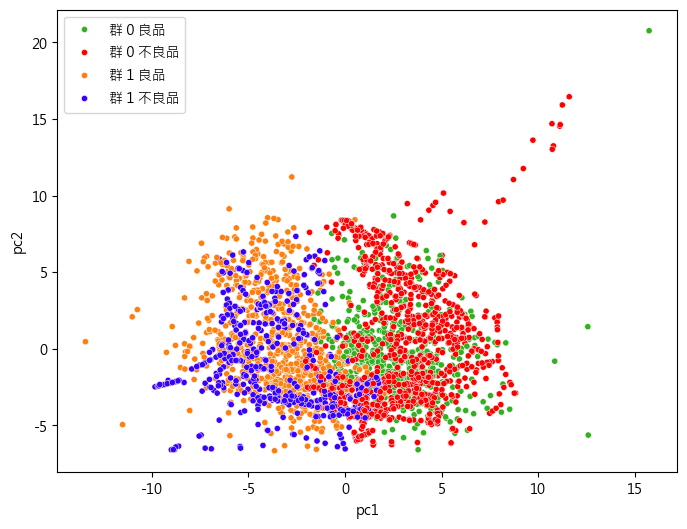

In [39]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=1, k_neighbors=5)
X_smote, y_smote = smote.fit_resample(X_std, y)
X_smote_df = pd.DataFrame(X_smote, columns=X_std.columns)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_smote_df)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
labels = kmeans.fit_predict(X_pca)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y_smote.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

X_pca_df['cluster'] = labels

X_pca_df['y'] = y_smote.values

# 建一個 4 類別欄位： (cluster, y)
X_pca_df['group'] = (
    '群' + ' ' + X_pca_df['cluster'].astype(str) + ' ' +
    X_pca_df['y'].map({0: '良品', 1: '不良品'})
)
# 這樣會有：C0_y0, C0_y1, C1_y0, C1_y1 四種

plt.figure(figsize=(8,6))
# 自訂 4 種顏色（可自行調整）
palette = {
    '群 0 良品': "#33B020",
    '群 0 不良品': "#ff0000",
    '群 1 良品': '#ff7f0e',
    '群 1 不良品': "#3700ff",
}

sns.scatterplot(
    data=X_pca_df,
    x=X_pca_df['pc1'], y=X_pca_df['pc2'],
    hue='group',
    palette=palette,
    s=20
)
plt.legend(loc='best')
plt.show(

)

PCA 保留 125 個主成分
PCA 保留 125 個主成分（以原始資料繪圖）
cluster sizes (original only): {0: 676, 1: 849}
cluster    0    1
y                
0        619  811
1         57   38


c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=12.
  warnings.warn(


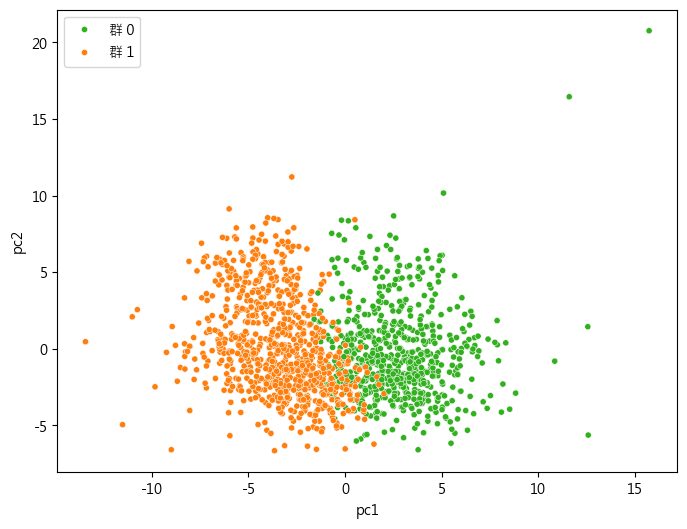

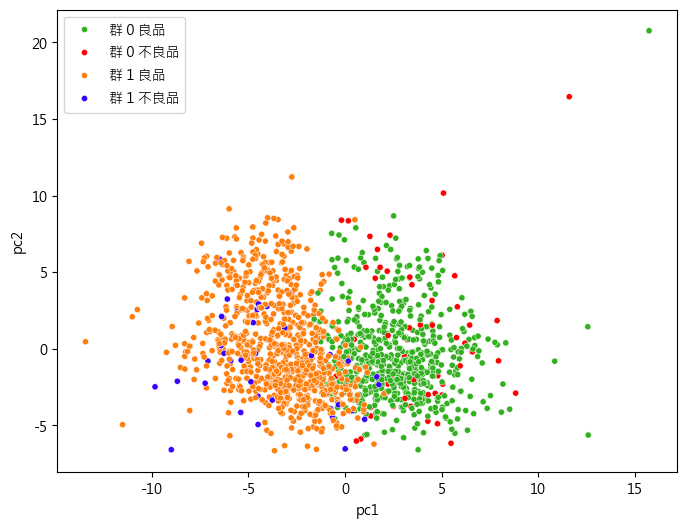

In [44]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=1, k_neighbors=5)
X_smote, y_smote = smote.fit_resample(X_std, y)
X_smote_df = pd.DataFrame(X_smote, columns=X_std.columns)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_smote_df)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
# 只取「原始資料」的 PCA 座標（用 X_std，不用 X_smote_df）
X_pca_org = pca.transform(X_std)
print(f'PCA 保留 {X_pca_org.shape[1]} 個主成分（以原始資料繪圖）')
X_pca_org_df = pd.DataFrame(
    X_pca_org,
    columns=[f'pc{i}' for i in range(1, X_pca_org.shape[1] + 1)],
    index=X_std.index
)

# --- KMeans：用 SMOTE 的 PCA 空間 fit（保持你原本分群依據），再對原始資料 predict ---
X_pca_smote = pca.transform(X_smote_df)
kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
kmeans.fit(X_pca_smote)

labels_org = kmeans.predict(X_pca_org)  # 原始樣本的 cluster
sizes = pd.Series(labels_org).value_counts().sort_index()
print('cluster sizes (original only):', sizes.to_dict())

# --- 列聯表：只用原始樣本（y 與 labels_org 長度一致） ---
df_org = pd.DataFrame({'y': y.values, 'label': labels_org})
ct = pd.crosstab(df_org['y'], df_org['label'], rownames=['y'], colnames=['cluster'])
print(ct)

# --- 繪圖資料：只含原始樣本 ---
X_pca_org_df['cluster'] = labels_org
X_pca_org_df['cluster'] = X_pca_org_df['cluster'].replace({0:'群 0', 1:'群 1'})
X_pca_org_df['y'] = y.values
X_pca_org_df['y'] = X_pca_org_df['y'].replace({0:'良品', 1:'不良品'})
X_pca_org_df['group'] = (X_pca_org_df['cluster'].astype(str) + ' ' + X_pca_org_df['y'].astype(str))

plt.figure(figsize=(8,6))
palette = {
    '群 0': "#33B020",  # cluster 1, y=1
    '群 1': '#ff7f0e',  # cluster 0, y=0
}
sns.scatterplot(data=X_pca_org_df, x=X_pca_org_df['pc1'], y=X_pca_org_df['pc2'], hue='cluster', s=20, palette=palette)
plt.legend(loc='best')
plt.show()

plt.figure(figsize=(8, 6))
palette = {
    '群 0 良品': "#33B020",  # cluster 0, y=0
    '群 0 不良品': "#ff0000",  # cluster 0, y=1
    '群 1 良品': '#ff7f0e',  # cluster 1, y=0
    '群 1 不良品': "#3700ff",  # cluster 1, y=1
}
sns.scatterplot(data=X_pca_org_df, x=X_pca_org_df['pc1'], y=X_pca_org_df['pc2'], hue='group', s=20, palette=palette)
plt.legend(loc='best')
plt.show()

In [8]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)
print(f'PCA極端值有:{outlier}, \n共{len(outlier)}個')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=1, k_neighbors=5)
X_smote, y_smote = smote.fit_resample(X_std, y)

# X_smote, y_smote 已經是你前面做完 SMOTE 後的標準化空間資料
X_smote_df = pd.DataFrame(X_smote, columns=X_std.columns)

# 1) 在同一個 SMOTE 空間做 PCA + KMeans，得到 cluster
pca = PCA(n_components=0.9, random_state=42)
X_pca = pca.fit_transform(X_smote_df)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
n_real = len(X_std)

# 必要斷言：確保前段就是原始點
assert np.allclose(X_smote_df.iloc[:n_real].values, X_std.values, atol=0, rtol=0)
assert np.array_equal(np.asarray(y_smote)[:n_real], np.asarray(y))

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
cluster = kmeans.fit_predict(X_pca)

# X_smote_df 目前包含所有特徵 + "cluster"
X_smote_df["cluster"] = cluster

# 確保 X_all_df 不含 cluster 欄
X_feat_df = X_smote_df.drop(columns=["cluster"]).copy()
# 只取真實點（不含 SMOTE 合成點）來做 local surrogate 與訓練每群 blackbox
X_all_df = X_feat_df.iloc[:n_real].copy() # 真實點特徵（標準化空間）
c_all = X_smote_df.loc[:n_real-1, "cluster"].to_numpy() # 真實點分群

y_real = np.asarray(y) # 真實 y

PCA 保留 131 個主成分
PCA極端值有:[8, 10, 14, 15, 23, 24, 25, 33, 36, 44, 46, 47, 51, 54, 57, 58, 61, 72, 84, 91, 93, 96, 99, 143, 144, 163, 172, 183, 186, 195, 196, 275, 457, 466, 539, 634, 709, 800, 1397, 1427, 1458, 1489], 
共42個
PCA 保留 125 個主成分


c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=12.
  warnings.warn(
C:\Users\No\AppData\Local\Temp\ipykernel_35564\1161096048.py:62: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_smote_df["cluster"] = cluster


In [5]:
def oof_proba_per_cluster(X_all_df, y_all, c_all, n_splits=5, random_state=42):
    """
    以分群為單位做 StratifiedKFold OOF，回傳每筆真實點的 OOF 機率 p_oof。
    每個 fold 的 training 內部再做 SMOTE，避免合成點寫回 OOF。
    """
    y_all = np.asarray(y_all).astype(int)
    p_oof = np.full(len(y_all), np.nan, dtype=float)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    for c in [0, 1]:
        idx = np.where(c_all == c)[0]
        Xc = X_all_df.iloc[idx].values
        yc = y_all[idx]

        for tr, te in skf.split(Xc, yc):
            X_tr, y_tr = Xc[tr], yc[tr]
            X_te = Xc[te]

            sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=random_state)
            X_tr, y_tr = sm.fit_resample(X_tr, y_tr)

            m = XGBClassifier(
                n_estimators=200,
                max_depth=3,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=10,
                gamma=1.0,
                reg_lambda=2.0,
                reg_alpha=0.5,
                random_state=random_state,
                n_jobs=-1,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
            )
            m.fit(X_tr, y_tr)
            p_oof[idx[te]] = m.predict_proba(X_te)[:, 1]

    return p_oof

p_hat_oof = oof_proba_per_cluster(X_all_df, y_real, c_all)

In [9]:
# 每筆樣本的預測類別（用 0.5 當分類門檻） 
pred_y = (p_hat_oof >= 0.5).astype(int) 
# 整理成一個總表 
result_df = X_all_df.copy() 
result_df["true_y"] = y_real 
result_df["pred_probability"] = p_hat_oof 
result_df["pred_y"] = pred_y 
result_df["cluster"] = c_all 

print(result_df[(abs(result_df["pred_probability"] - 1) <= 0.2)&(result_df['cluster']==0)].sort_values('pred_probability',ascending=False).iloc[:,-4:], f"　len:{len(result_df[(abs(result_df["pred_probability"] - 1) <= 0.2)&(result_df['cluster']==0)].sort_values('pred_probability',ascending=False).iloc[:,-4:])}")
print(result_df[(abs(result_df["pred_probability"] - 1) <= 0.2)&(result_df['cluster']==1)].sort_values('pred_probability',ascending=False).iloc[:,-4:], f"　len:{len(result_df[(abs(result_df["pred_probability"] - 1) <= 0.2)&(result_df['cluster']==1)].sort_values('pred_probability',ascending=False).iloc[:,-4:])}")
print(result_df[(abs(result_df["pred_probability"] - 1) <= 0.2)&(result_df['cluster']==2)].sort_values('pred_probability',ascending=False).iloc[:,-4:], f"　len:{len(result_df[(abs(result_df["pred_probability"] - 1) <= 0.2)&(result_df['cluster']==2)].sort_values('pred_probability',ascending=False).iloc[:,-4:])}")
print(result_df[(abs(result_df["pred_probability"] - 1) <= 0.2)&(result_df['cluster']==3)].sort_values('pred_probability',ascending=False).iloc[:,-4:], f"　len:{len(result_df[(abs(result_df["pred_probability"] - 1) <= 0.2)&(result_df['cluster']==3)].sort_values('pred_probability',ascending=False).iloc[:,-4:])}")

print(result_df[(abs(result_df["pred_probability"] - 0.5) <= 0.05)&(result_df['cluster']==0)].sort_values('pred_probability',ascending=False).iloc[:,-4:], f"　len:{len(result_df[(abs(result_df["pred_probability"] - 0.5) <= 0.05)&(result_df['cluster']==0)].sort_values('pred_probability',ascending=False).iloc[:,-4:])}")
print(result_df[(abs(result_df["pred_probability"] - 0.5) <= 0.05)&(result_df['cluster']==1)].sort_values('pred_probability',ascending=False).iloc[:,-4:], f"　len:{len(result_df[(abs(result_df["pred_probability"] - 0.5) <= 0.05)&(result_df['cluster']==1)].sort_values('pred_probability',ascending=False).iloc[:,-4:])}")
print(result_df[(abs(result_df["pred_probability"] - 0.5) <= 0.05)&(result_df['cluster']==2)].sort_values('pred_probability',ascending=False).iloc[:,-4:], f"　len:{len(result_df[(abs(result_df["pred_probability"] - 0.5) <= 0.05)&(result_df['cluster']==2)].sort_values('pred_probability',ascending=False).iloc[:,-4:])}")
print(result_df[(abs(result_df["pred_probability"] - 0.5) <= 0.05)&(result_df['cluster']==3)].sort_values('pred_probability',ascending=False).iloc[:,-4:], f"　len:{len(result_df[(abs(result_df["pred_probability"] - 0.5) <= 0.05)&(result_df['cluster']==3)].sort_values('pred_probability',ascending=False).iloc[:,-4:])}")


     true_y  pred_probability  pred_y  cluster
348       0          0.975609       1        0 　len:1
     true_y  pred_probability  pred_y  cluster
212       1          0.848101       1        1 　len:1
      true_y  pred_probability  pred_y  cluster
1326       1          0.846026       1        2 　len:1
      true_y  pred_probability  pred_y  cluster
1056       0          0.843086       1        3 　len:1
     true_y  pred_probability  pred_y  cluster
247       0          0.544061       1        0
111       0          0.457258       0        0 　len:2
     true_y  pred_probability  pred_y  cluster
109       0          0.548989       1        1
653       0          0.548375       1        1
144       0          0.527558       1        1
225       0          0.516134       1        1
82        0          0.498364       0        1
44        0          0.481022       0        1
298       0          0.468458       0        1
105       0          0.458454       0        1 　len:8
      true_y  

# Baseline

In [6]:
# 各群原始參數
xgb_params_baseline = {
    0: {
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "tree_method": "hist",
    },
    1: {
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "tree_method": "hist",
    }
}

def oof_proba_per_cluster(
    X_all_df,
    y_all,
    c_all,
    xgb_params_by_cluster,
    n_splits=5,
    random_state=42,
    smote_sampling_strategy=0.3,
    smote_k_neighbors=3
):
    """
    以分群為單位做 StratifiedKFold OOF。

    每一群使用該群對應的 XGBoost 參數。
    每個 fold 的 training 內部再做 SMOTE。
    OOF 機率只寫回真實樣本，不寫入合成樣本。
    """

    y_all = np.asarray(y_all).astype(int)
    c_all = np.asarray(c_all)

    p_oof = np.full(len(y_all), np.nan, dtype=float)

    for c in sorted(np.unique(c_all)):

        idx = np.where(c_all == c)[0]
        Xc = X_all_df.iloc[idx].values
        yc = y_all[idx]

        params = xgb_params_by_cluster[c].copy()

        skf = StratifiedKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=random_state
        )

        for fold_id, (tr, te) in enumerate(skf.split(Xc, yc), start=1):

            X_tr, y_tr = Xc[tr], yc[tr]
            X_te = Xc[te]

            sm = SMOTE(
                sampling_strategy=smote_sampling_strategy,
                k_neighbors=smote_k_neighbors,
                random_state=random_state
            )

            X_tr_sm, y_tr_sm = sm.fit_resample(X_tr, y_tr)

            m = XGBClassifier(
                **params,
                random_state=random_state,
                n_jobs=-1
            )

            m.fit(X_tr_sm, y_tr_sm)

            p_oof[idx[te]] = m.predict_proba(X_te)[:, 1]

    return p_oof


p_hat_oof = oof_proba_per_cluster(
    X_all_df=X_all_df,
    y_all=y_real,
    c_all=c_all,
    xgb_params_by_cluster=xgb_params_baseline,
    n_splits=5,
    random_state=42
)


df_proba = pd.DataFrame({
    "global_idx": np.arange(len(y_real)),
    "cluster": c_all,
    "y_true": y_real,
    "p_hat_oof": p_hat_oof
})


print("\n高機率樣本（由大到小）:")
print(df_proba.sort_values("p_hat_oof", ascending=False).head(20))


# 檢查是否有 OOF 沒被寫入
print("\nOOF missing count:")
print(df_proba["p_hat_oof"].isna().sum())



高機率樣本（由大到小）:
      global_idx  cluster  y_true  p_hat_oof
348          348        0       0   0.983401
176          176        0       0   0.953209
210          210        0       1   0.892711
34            34        0       0   0.796035
1326        1326        1       1   0.720269
212          212        0       1   0.671055
1361        1361        1       1   0.647832
273          273        0       0   0.584404
214          214        0       0   0.572031
374          374        0       1   0.565107
1054        1054        1       0   0.562458
111          111        0       0   0.560185
222          222        0       0   0.548319
181          181        0       0   0.544286
108          108        0       1   0.512653
206          206        0       0   0.500793
211          211        0       0   0.472920
136          136        0       0   0.472363
44            44        0       0   0.461306
178          178        0       0   0.460857

OOF missing count:
0


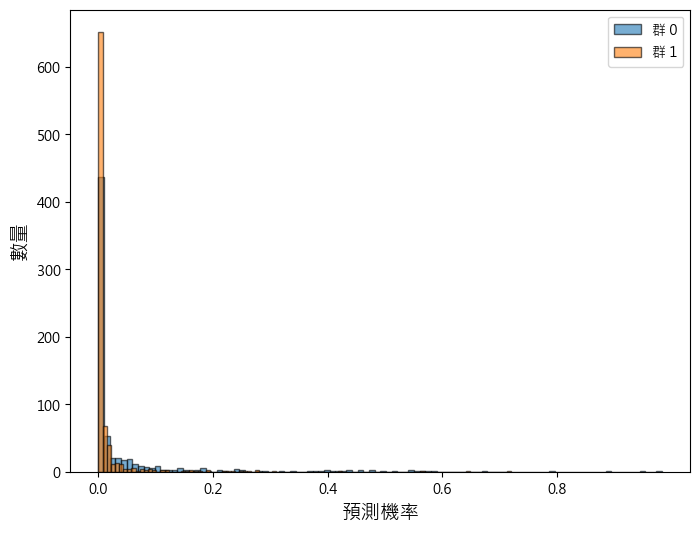

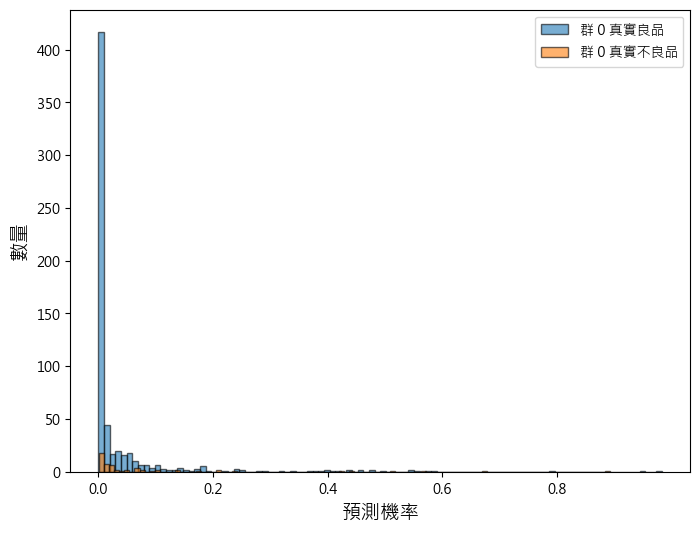

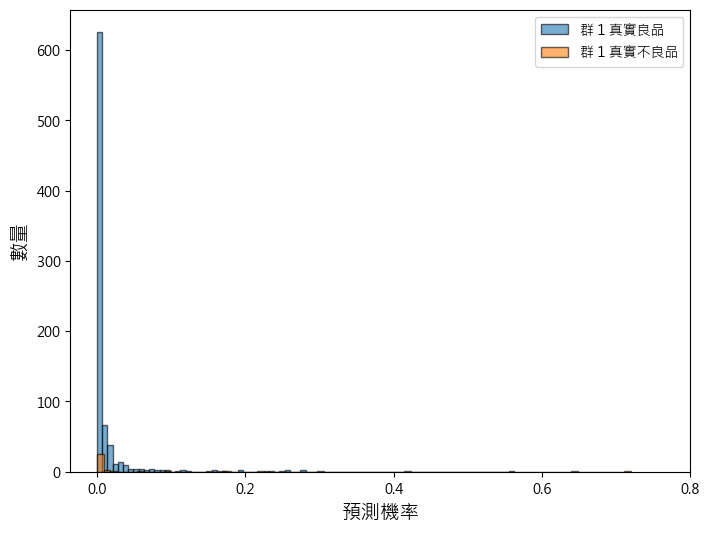

In [7]:
def hist_count(
    data_list,
    label_list,
    bins=100,
    xlabel="預測機率",
    ylabel="數量",
    title=None,
    figsize=(8, 6)
):
    plt.figure(figsize=figsize)

    for data, label in zip(data_list, label_list):
        p = pd.Series(data).dropna().values

        if len(p) == 0:
            continue

        plt.hist(
            p,
            bins=bins,
            alpha=0.6,
            label=label,
            edgecolor="black"
        )
    plt.xticks(np.arange(0, 0.81, 0.2))
    plt.xlabel(xlabel, fontsize=14)
    plt.ylabel(ylabel, fontsize=14)

    if title is not None:
        plt.title(title)

    plt.legend()
    plt.show()
    
# 1) 各群使用各自 XGBoost 參數後的機率分布圖
hist_count(
    data_list=[
        df_proba.loc[df_proba["cluster"] == 0, "p_hat_oof"],
        df_proba.loc[df_proba["cluster"] == 1, "p_hat_oof"]
    ],
    label_list=[
        "群 0",
        "群 1"
    ],
    bins=100,
    xlabel="預測機率",
    ylabel="數量"
)

# 2) 群 0 內部：依真實類別分布
df_c0 = df_proba[df_proba["cluster"] == 0]

hist_count(
    data_list=[
        df_c0.loc[df_c0["y_true"] == 0, "p_hat_oof"],
        df_c0.loc[df_c0["y_true"] == 1, "p_hat_oof"]
    ],
    label_list=[
        "群 0 真實良品",
        "群 0 真實不良品"
    ],
    bins=100,
    xlabel="預測機率",
    ylabel="數量"
)


# 3) 群 1 內部：依真實類別分布
df_c1 = df_proba[df_proba["cluster"] == 1]

hist_count(
    data_list=[
        df_c1.loc[df_c1["y_true"] == 0, "p_hat_oof"],
        df_c1.loc[df_c1["y_true"] == 1, "p_hat_oof"]
    ],
    label_list=[
        "群 1 真實良品",
        "群 1 真實不良品"
    ],
    bins=80,
    xlabel="預測機率",
    ylabel="數量"
)

In [9]:
df_proba_baseline = pd.DataFrame({
    "y_true": np.asarray(y_real).astype(int),
    "cluster": np.asarray(c_all),
    "p_hat_oof": p_hat_oof
})
def binary_metrics_at_threshold(y_true, p_hat, threshold=0.5):
    """
    y_true: 真實標籤，0=良品，1=不良品
    p_hat : 預測為不良品的機率
    threshold: 判定為不良品的門檻
    """

    y_true = np.asarray(y_true).astype(int)
    p_hat = np.asarray(p_hat).astype(float)

    y_pred = (p_hat >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()
    acc = accuracy_score(y_true, y_pred)
    recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    far = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else np.nan
    )

    return {
        "ACC": acc,
        "Recall": recall,
        "FAR": far,
        "Precision": precision,
        "F1-score": f1,
        "TP": tp,
        "FP": fp
    }
def baseline_metrics_by_cluster_threshold(
    df_proba,
    thresholds=[0.2, 0.5]
):
    rows = []

    for c in sorted(df_proba["cluster"].unique()):

        df_c = df_proba[df_proba["cluster"] == c].copy()

        for th in thresholds:

            metrics = binary_metrics_at_threshold(
                y_true=df_c["y_true"],
                p_hat=df_c["p_hat_oof"],
                threshold=th
            )

            rows.append({
                "群別": c,
                "threshold": th,
                **metrics
            })

    result = pd.DataFrame(rows)

    result = result[
        [
            "群別",
            "threshold",
            "ACC",
            "Recall",
            "FAR",
            "Precision",
            "F1-score",
            "TP",
            "FP"
        ]
    ]

    return result
baseline_result = baseline_metrics_by_cluster_threshold(
    df_proba=df_proba_baseline,
    thresholds=[0.2, 0.5]
)

baseline_result

baseline_result_display = baseline_result.copy()

baseline_result_display[
    ["ACC", "Recall", "FAR", "Precision", "F1-score"]
] = baseline_result_display[
    ["ACC", "Recall", "FAR", "Precision", "F1-score"]
].round(4)

baseline_result_display

NameError: name 'p_hat_oof' is not defined

# 最佳參數

In [10]:
# 各群最佳參數
xgb_params_by_cluster = {
    0: {
        "n_estimators": 500,
        "max_depth": 3,
        "learning_rate": 0.03,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "min_child_weight": 5,
        "gamma": 1.0,
        "reg_lambda": 2.0,
        "reg_alpha": 0.5,
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "tree_method": "hist",
    },
    1: {
        "n_estimators": 500,
        "max_depth": 3,
        "learning_rate": 0.03,
        "subsample": 0.6,
        "colsample_bytree": 0.6,
        "min_child_weight": 1,
        "gamma": 0,
        "reg_lambda": 1.0,
        "reg_alpha": 0.0,
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "tree_method": "hist",
    }
}


def oof_proba_per_cluster(
    X_all_df,
    y_all,
    c_all,
    xgb_params_by_cluster,
    n_splits=5,
    random_state=42,
    smote_sampling_strategy=0.3,
    smote_k_neighbors=3
):
    """
    以分群為單位做 StratifiedKFold OOF。

    每一群使用該群對應的 XGBoost 參數。
    每個 fold 的 training 內部再做 SMOTE。
    OOF 機率只寫回真實樣本，不寫入合成樣本。
    """

    y_all = np.asarray(y_all).astype(int)
    c_all = np.asarray(c_all)

    p_oof = np.full(len(y_all), np.nan, dtype=float)

    for c in sorted(np.unique(c_all)):

        idx = np.where(c_all == c)[0]
        Xc = X_all_df.iloc[idx].values
        yc = y_all[idx]

        params = xgb_params_by_cluster[c].copy()

        skf = StratifiedKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=random_state
        )

        for fold_id, (tr, te) in enumerate(skf.split(Xc, yc), start=1):

            X_tr, y_tr = Xc[tr], yc[tr]
            X_te = Xc[te]

            sm = SMOTE(
                sampling_strategy=smote_sampling_strategy,
                k_neighbors=smote_k_neighbors,
                random_state=random_state
            )

            X_tr_sm, y_tr_sm = sm.fit_resample(X_tr, y_tr)

            m = XGBClassifier(
                **params,
                random_state=random_state,
                n_jobs=-1
            )

            m.fit(X_tr_sm, y_tr_sm)

            p_oof[idx[te]] = m.predict_proba(X_te)[:, 1]

    return p_oof


p_hat_oof = oof_proba_per_cluster(
    X_all_df=X_all_df,
    y_all=y_real,
    c_all=c_all,
    xgb_params_by_cluster=xgb_params_by_cluster,
    n_splits=5,
    random_state=42
)


df_proba = pd.DataFrame({
    "global_idx": np.arange(len(y_real)),
    "cluster": c_all,
    "y_true": y_real,
    "p_hat_oof": p_hat_oof
})


print("\n高機率樣本（由大到小）:")
print(df_proba.sort_values("p_hat_oof", ascending=False).head(20))


# 檢查是否有 OOF 沒被寫入
print("\nOOF missing count:")
print(df_proba["p_hat_oof"].isna().sum())



高機率樣本（由大到小）:
      global_idx  cluster  y_true  p_hat_oof
348          348        0       0   0.888435
210          210        0       1   0.731492
176          176        0       0   0.726403
178          178        0       0   0.702333
136          136        0       0   0.665274
1326        1326        1       1   0.635248
212          212        0       1   0.615848
34            34        0       0   0.600244
374          374        0       1   0.574288
109          109        0       0   0.537340
1361        1361        1       1   0.536508
44            44        0       0   0.523004
153          153        0       1   0.517496
144          144        0       0   0.497951
134          134        0       0   0.492272
96            96        0       0   0.490516
142          142        0       0   0.490152
196          196        0       0   0.467398
206          206        0       0   0.452504
378          378        0       0   0.447836

OOF missing count:
0


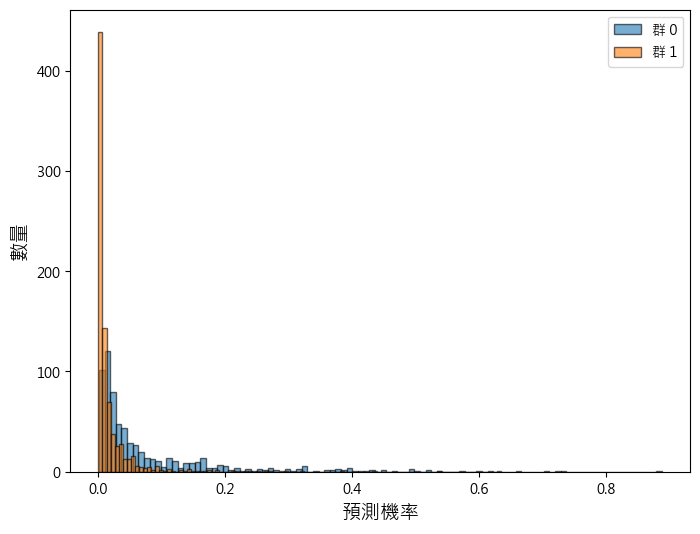

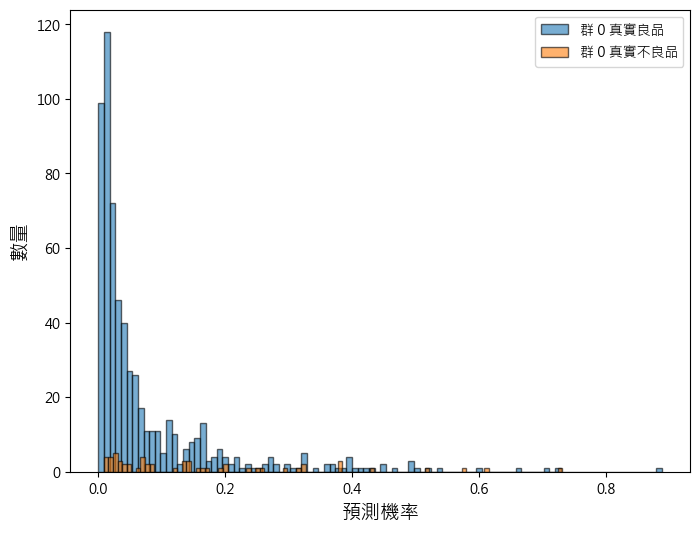

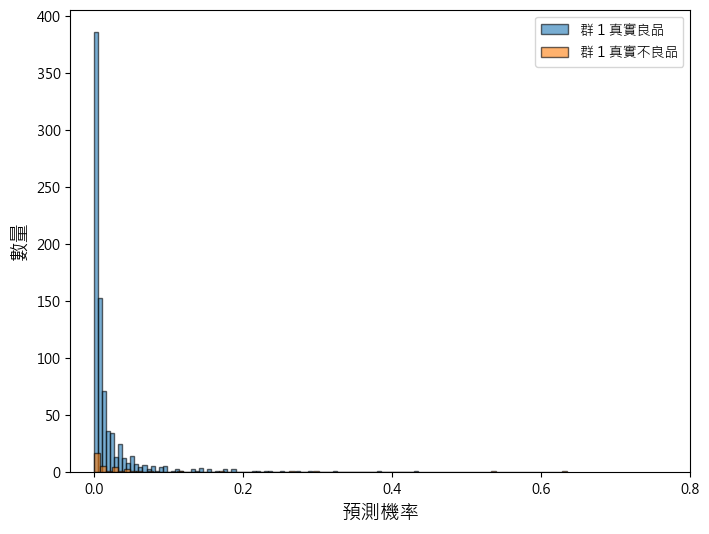

In [11]:
def hist_count(
    data_list,
    label_list,
    bins=100,
    xlabel="預測機率",
    ylabel="數量",
    title=None,
    figsize=(8, 6)
):
    plt.figure(figsize=figsize)

    for data, label in zip(data_list, label_list):
        p = pd.Series(data).dropna().values

        if len(p) == 0:
            continue

        plt.hist(
            p,
            bins=bins,
            alpha=0.6,
            label=label,
            edgecolor="black"
        )
    plt.xticks(np.arange(0, 0.81, 0.2))
    plt.xlabel(xlabel, fontsize=14)
    plt.ylabel(ylabel, fontsize=14)

    if title is not None:
        plt.title(title)

    plt.legend()
    plt.show()
    
# 1) 各群使用各自 XGBoost 參數後的機率分布圖
hist_count(
    data_list=[
        df_proba.loc[df_proba["cluster"] == 0, "p_hat_oof"],
        df_proba.loc[df_proba["cluster"] == 1, "p_hat_oof"]
    ],
    label_list=[
        "群 0",
        "群 1"
    ],
    bins=100,
    xlabel="預測機率",
    ylabel="數量"
)

# 2) 群 0 內部：依真實類別分布
df_c0 = df_proba[df_proba["cluster"] == 0]

hist_count(
    data_list=[
        df_c0.loc[df_c0["y_true"] == 0, "p_hat_oof"],
        df_c0.loc[df_c0["y_true"] == 1, "p_hat_oof"]
    ],
    label_list=[
        "群 0 真實良品",
        "群 0 真實不良品"
    ],
    bins=100,
    xlabel="預測機率",
    ylabel="數量"
)


# 3) 群 1 內部：依真實類別分布
df_c1 = df_proba[df_proba["cluster"] == 1]

hist_count(
    data_list=[
        df_c1.loc[df_c1["y_true"] == 0, "p_hat_oof"],
        df_c1.loc[df_c1["y_true"] == 1, "p_hat_oof"]
    ],
    label_list=[
        "群 1 真實良品",
        "群 1 真實不良品"
    ],
    bins=80,
    xlabel="預測機率",
    ylabel="數量"
)

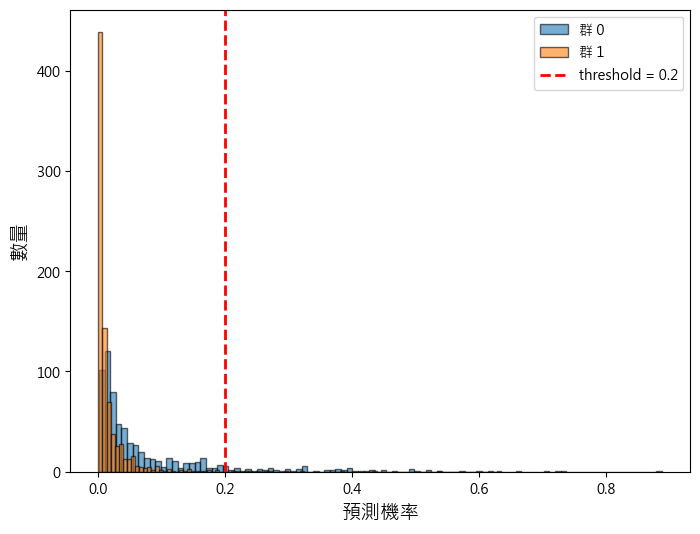

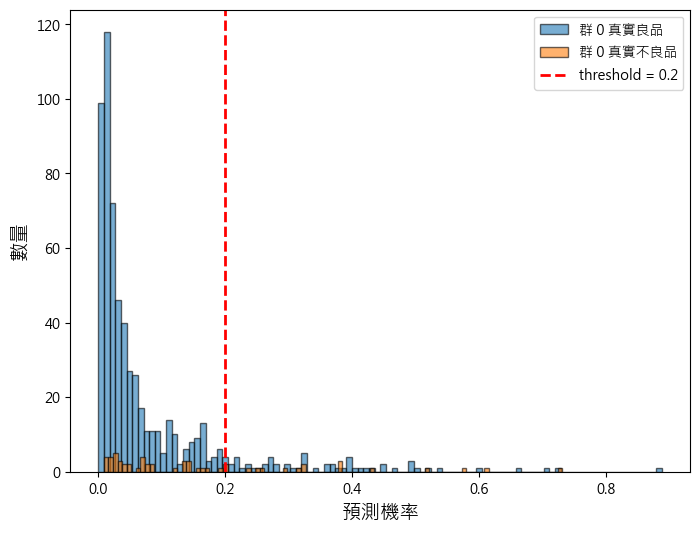

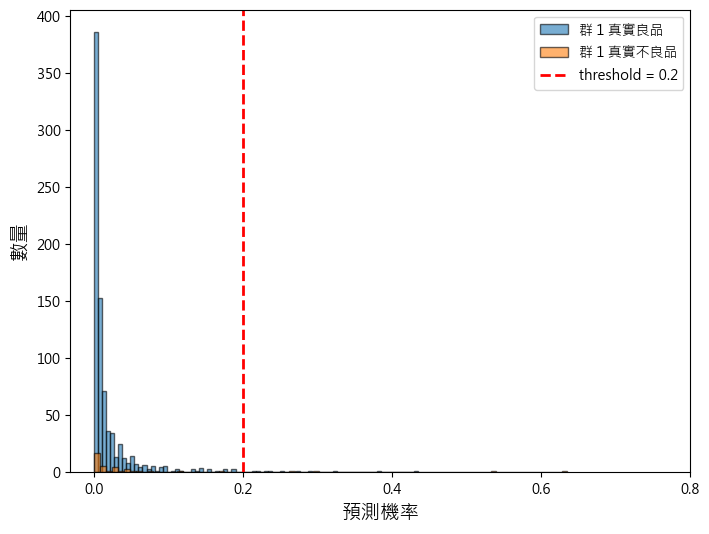

In [13]:
def hist_count(
    data_list,
    label_list,
    bins=100,
    xlabel="預測機率",
    ylabel="數量",
    title=None,
    figsize=(8, 6),
    threshold=0.2
):
    plt.figure(figsize=figsize)

    for data, label in zip(data_list, label_list):
        p = pd.Series(data).dropna().values

        if len(p) == 0:
            continue

        plt.hist(
            p,
            bins=bins,
            alpha=0.6,
            label=label,
            edgecolor="black"
        )
        # 加入 threshold 垂直線
    plt.axvline(
        x=threshold,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"threshold = {threshold}"
    )

    plt.xticks(np.arange(0, 0.81, 0.2))
    plt.xlabel(xlabel, fontsize=14)
    plt.ylabel(ylabel, fontsize=14)

    if title is not None:
        plt.title(title)

    plt.legend()
    plt.show()
    
# 1) 各群使用各自 XGBoost 參數後的機率分布圖
hist_count(
    data_list=[
        df_proba.loc[df_proba["cluster"] == 0, "p_hat_oof"],
        df_proba.loc[df_proba["cluster"] == 1, "p_hat_oof"]
    ],
    label_list=[
        "群 0",
        "群 1"
    ],
    bins=100,
    xlabel="預測機率",
    ylabel="數量"
)

# 2) 群 0 內部：依真實類別分布
df_c0 = df_proba[df_proba["cluster"] == 0]

hist_count(
    data_list=[
        df_c0.loc[df_c0["y_true"] == 0, "p_hat_oof"],
        df_c0.loc[df_c0["y_true"] == 1, "p_hat_oof"]
    ],
    label_list=[
        "群 0 真實良品",
        "群 0 真實不良品"
    ],
    bins=100,
    xlabel="預測機率",
    ylabel="數量"
)


# 3) 群 1 內部：依真實類別分布
df_c1 = df_proba[df_proba["cluster"] == 1]

hist_count(
    data_list=[
        df_c1.loc[df_c1["y_true"] == 0, "p_hat_oof"],
        df_c1.loc[df_c1["y_true"] == 1, "p_hat_oof"]
    ],
    label_list=[
        "群 1 真實良品",
        "群 1 真實不良品"
    ],
    bins=80,
    xlabel="預測機率",
    ylabel="數量"
)

In [ ]:
from scipy.stats import gaussian_kde

# 4) 整體機率分布
p = df_proba["p_hat_oof"].dropna().values

bins = 100
plt.figure(figsize=(8, 6))
counts, bin_edges, _ = plt.hist(
    p,
    bins=bins,
    alpha=0.6,
    edgecolor="black"
)

bin_width = bin_edges[1] - bin_edges[0]

kde = gaussian_kde(p)
x_grid = np.linspace(0, 1, 500)

# KDE 密度轉成預期數量
plt.plot(
    x_grid,
    kde(x_grid) * len(p) * bin_width,
    linewidth=2
)

plt.xlabel("預測機率", fontsize=14)
plt.ylabel("數量", fontsize=14)
plt.show()

In [10]:
def compute_metrics(y_true, y_pred, y_score):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP = cm[0, 0], cm[0, 1]
    acc = accuracy_score(y_true, y_pred)
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    ROCAU = roc_auc_score(y_true, y_score) if np.unique(y_true).size == 2 else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'ROCAU':ROCAU}

def predict_score(clf, X):
    if hasattr(clf, "predict_proba"):
        return clf.predict_proba(X)[:, 1]
    if hasattr(clf, "decision_function"):
        s = clf.decision_function(X)
        return 1 / (1 + np.exp(-s))
    return clf.predict(X).astype(float)

def predict_labels(clf, X):
    # 機率→阈值0.5；否則 decision_function → 阈值0
    if hasattr(clf, "predict_proba"):
        return (clf.predict_proba(X)[:,1] >= 0.5).astype(int)
    if hasattr(clf, "decision_function"):
        return (clf.decision_function(X) >= 0.0).astype(int)
    return clf.predict(X)

# ====== 新增：bootstrap CI（用 OOF 預測做抽樣）======
def bootstrap_ci_from_oof(y_true, y_score, thr=0.5, B=10000, alpha=0.05, seed=42):
    """
    y_true: (n,) 0/1
    y_score: (n,) OOF predicted proba for positive class (Fail)
    回傳：point estimate + percentile 95% CI for ACC, FAR, ROCAU
    """
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    n = len(y_true)
    rng = np.random.default_rng(seed)

    def met_on_arrays(yt, ys):
        yp = (ys >= thr).astype(int)
        m = compute_metrics(yt, yp, ys)
        return m['acc'], m['FAR'], m['ROCAU']

    # point
    p_acc, p_far, p_auc = met_on_arrays(y_true, y_score)

    # bootstrap
    boots = np.empty((B, 3), dtype=float)
    for b in range(B):
        idx = rng.integers(0, n, size=n)  # sample with replacement
        boots[b, :] = met_on_arrays(y_true[idx], y_score[idx])

    lo = np.nanquantile(boots, alpha / 2, axis=0)
    hi = np.nanquantile(boots, 1 - alpha / 2, axis=0)

    return {
        "ACC": (p_acc, lo[0], hi[0]),
        "FAR": (p_far, lo[1], hi[1]),
        "ROCAU": (p_auc, lo[2], hi[2]),
        "boots": boots
    }



=== XGBoost ===
Fold 1: acc=0.925, FAR=0.017, ROCAU=0.615
Fold 2: acc=0.921, FAR=0.028, ROCAU=0.695
Fold 3: acc=0.931, FAR=0.010, ROCAU=0.614
Fold 4: acc=0.921, FAR=0.021, ROCAU=0.708
Fold 5: acc=0.938, FAR=0.017, ROCAU=0.685

Confusion matrix (mean over 5 folds):
[[280.6   5.4]
 [ 16.8   2.2]]

OOF Bootstrap 95% CI (percentile):
ACC  = 0.9272 [0.9141, 0.9397]
FAR  = 0.0189 [0.0120, 0.0264]
ROCAU= 0.6623 [0.6054, 0.7178]


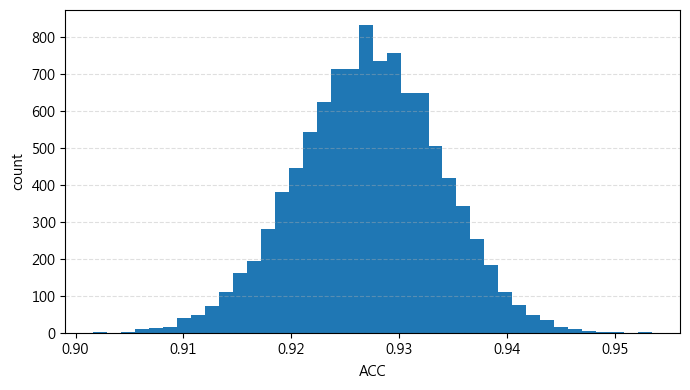

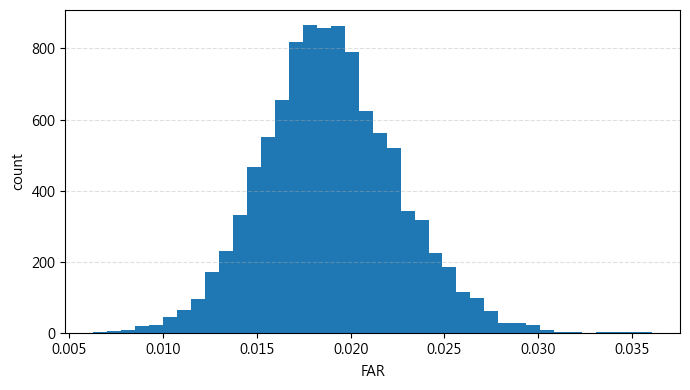

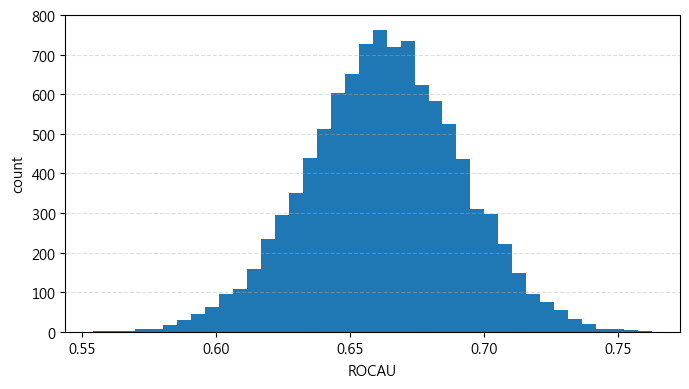


Summary (5-Fold mean):
             acc     FAR   ROCAU
model                          
XGBoost  0.9272  0.0189  0.6636


In [ ]:
model = {'XGBoost':XGBClassifier(
                    n_estimators=200,
                    max_depth=3,
                    learning_rate=0.1,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    min_child_weight=10,
                    gamma=1.0,
                    reg_lambda=2.0,
                    reg_alpha=0.5,
                    random_state=42,
                    n_jobs=-1,
                    objective="binary:logistic",
                    eval_metric="logloss",
                    tree_method="hist",)}

# ====== 五摺交叉驗證 ======
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []
for name, clf in model.items():
    fold_metrics = []
    cm_sum = np.zeros((2, 2), dtype=float)

    # ====== 新增：OOF 儲存（每筆樣本只會被填一次）======
    oof_score = np.full(len(y_real), np.nan, dtype=float)  # OOF proba for positive class
    oof_true  = np.full(len(y_real), np.nan, dtype=float)  # store y_true for safety
    # ================================================

    print(f"\n=== {name} ===")
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_all_df, y_real), 1):
        Xtr, Xte = X_all_df.iloc[train_idx], X_all_df.iloc[test_idx]
        ytr, yte = y_real[train_idx], y_real[test_idx]

        # 只對訓練集做 SMOTE
        smote = SMOTE(random_state=42, sampling_strategy=1, k_neighbors=5)
        Xtr_res, ytr_res = smote.fit_resample(Xtr, ytr)

        m = clone(clf)
        m.fit(Xtr_res, ytr_res)
        yhat = predict_labels(m, Xte)
        ys   = predict_score(m, Xte)
        
        # ====== 新增：寫入 OOF ======
        oof_score[test_idx] = ys
        oof_true[test_idx] = yte
        # ==========================

        met  = compute_metrics(yte, yhat, ys)
        fold_metrics.append(met)
        cm_sum += met["cm"]
        print(f"Fold {fold}: acc={met['acc']:.3f}, FAR={met['FAR']:.3f}, ROCAU={met['ROCAU']:.3f}")

    # 平均每個 fold 的結果
    avg_metrics = pd.DataFrame(fold_metrics).drop(columns='cm').mean().to_dict()
    avg_metrics['model'] = name
    cv_results.append(avg_metrics)

    # 額外輸出：5 折平均 confusion matrix
    cm_mean = cm_sum / skf.get_n_splits()
    print("\nConfusion matrix (mean over 5 folds):")
    print(cm_mean)
    
    # ====== 新增：OOF bootstrap 95% CI ======
    # 注意：OOF 應該全部被填滿；若有 nan 代表流程有 bug
    valid = ~np.isnan(oof_score)
    ci = bootstrap_ci_from_oof(oof_true[valid], oof_score[valid], thr=0.5, B=10000, alpha=0.05, seed=42)
    print("\nOOF Bootstrap 95% CI (percentile):")
    print(f"ACC  = {ci['ACC'][0]:.4f} [{ci['ACC'][1]:.4f}, {ci['ACC'][2]:.4f}]")
    print(f"FAR  = {ci['FAR'][0]:.4f} [{ci['FAR'][1]:.4f}, {ci['FAR'][2]:.4f}]")
    print(f"ROCAU= {ci['ROCAU'][0]:.4f} [{ci['ROCAU'][1]:.4f}, {ci['ROCAU'][2]:.4f}]")
    
    # （可選）畫 bootstrap 分佈：三個指標各一張
    boots = ci["boots"]
    for j, lab in enumerate(["ACC", "FAR", "ROCAU"]):
        plt.figure(figsize=(7,4))
        plt.hist(boots[:, j][~np.isnan(boots[:, j])], bins=40)
        plt.xlabel(lab); plt.ylabel("count")
        plt.grid(True, axis="y", linestyle="--", alpha=0.4)
        plt.tight_layout()
        plt.show()
    # =====================================

# ====== 結果輸出 ======
metrics_df = pd.DataFrame(cv_results).set_index('model').loc[model.keys()]
print("\nSummary (5-Fold mean):\n", metrics_df.round(4))

In [1]:
FIXED_SMOTE_RATIO = 0.3
FIXED_THRESHOLD = 0.2
FIXED_K_NEIGHBORS = 3

def binary_metrics(y_true, y_score, threshold=0.5):
    y_pred = (y_score >= threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    acc = (tp + tn) / (tp + tn + fp + fn)

    far = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else np.nan
    )

    try:
        rocauc = roc_auc_score(y_true, y_score)
    except:
        rocauc = np.nan

    return {
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "ACC": acc,
        "FAR": far,
        "Recall": recall,
        "Precision": precision,
        "F1": f1,
        "ROCAU": rocauc,
        "cm": cm
    }

# ===============================
# XGBoost 參數組合
# ===============================

xgb_param_grid = {
    "M1_current": {
        "n_estimators": 500,
        "max_depth": 3,
        "learning_rate": 0.03,
        "min_child_weight": 1,
        "gamma": 0,
        "reg_lambda": 1.0,
        "reg_alpha": 0.0,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    },
    "M2_shallow_regularized": {
        "n_estimators": 500,
        "max_depth": 2,
        "learning_rate": 0.03,
        "min_child_weight": 3,
        "gamma": 0.5,
        "reg_lambda": 2.0,
        "reg_alpha": 0.5,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    },
    "M3_deeper": {
        "n_estimators": 500,
        "max_depth": 4,
        "learning_rate": 0.03,
        "min_child_weight": 1,
        "gamma": 0,
        "reg_lambda": 1.0,
        "reg_alpha": 0.0,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    },
    "M4_more_trees_low_lr": {
        "n_estimators": 800,
        "max_depth": 3,
        "learning_rate": 0.02,
        "min_child_weight": 1,
        "gamma": 0,
        "reg_lambda": 1.0,
        "reg_alpha": 0.0,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    },
    "M5_conservative_split": {
        "n_estimators": 500,
        "max_depth": 3,
        "learning_rate": 0.03,
        "min_child_weight": 5,
        "gamma": 1.0,
        "reg_lambda": 2.0,
        "reg_alpha": 0.5,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    },
    "M6_more_randomized": {
        "n_estimators": 500,
        "max_depth": 3,
        "learning_rate": 0.03,
        "min_child_weight": 1,
        "gamma": 0,
        "reg_lambda": 1.0,
        "reg_alpha": 0.0,
        "subsample": 0.6,
        "colsample_bytree": 0.6,
    },
}

# ===============================
# CV 設定
# ===============================

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_fold_rows = []
all_oof_rows = []

# ===============================
# 主迴圈：XGBoost 參數組合 × CV fold
# ===============================

for model_name, params in xgb_param_grid.items():

    print("\n" + "=" * 80)
    print(f"Model setting: {model_name}")
    print("=" * 80)

    oof_score = np.full(len(y_real), np.nan, dtype=float)
    oof_true = np.full(len(y_real), np.nan, dtype=float)

    for fold, (train_idx, test_idx) in enumerate(skf.split(X_all_df, y_real), 1):

        Xtr, Xte = X_all_df[train_idx], X_all_df[test_idx]
        ytr, yte = y_real[train_idx], y_real[test_idx]

        print(f"\nFold {fold}")

        smote = SMOTE(
            random_state=42,
            sampling_strategy=FIXED_SMOTE_RATIO,
            k_neighbors=FIXED_K_NEIGHBORS
        )

        Xtr_res, ytr_res = smote.fit_resample(Xtr, ytr)

        model = XGBClassifier(
            **params,
            random_state=42,
            n_jobs=-1,
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
        )

        model.fit(Xtr_res, ytr_res)

        ys = model.predict_proba(Xte)[:, 1]

        # 寫入 OOF
        oof_score[test_idx] = ys
        oof_true[test_idx] = yte

        # 固定 threshold = 0.2
        met = binary_metrics(yte, ys, threshold=FIXED_THRESHOLD)

        all_fold_rows.append({
            "model_setting": model_name,
            "fold": fold,
            "SMOTE_ratio": FIXED_SMOTE_RATIO,
            "threshold": FIXED_THRESHOLD,
            "TN": met["TN"],
            "FP": met["FP"],
            "FN": met["FN"],
            "TP": met["TP"],
            "ACC": met["ACC"],
            "FAR": met["FAR"],
            "Recall": met["Recall"],
            "Precision": met["Precision"],
            "F1": met["F1"],
            "ROCAU": met["ROCAU"],
            **params
        })

        print(
            f"thr={FIXED_THRESHOLD:.1f} | "
            f"ACC={met['ACC']:.4f}, "
            f"FAR={met['FAR']:.4f}, "
            f"Recall={met['Recall']:.4f}, "
            f"Precision={met['Precision']:.4f}, "
            f"F1={met['F1']:.4f}, "
            f"ROCAU={met['ROCAU']:.4f}"
        )

    # ===============================
    # OOF 整體分析
    # ===============================

    valid = (~np.isnan(oof_score)) & (~np.isnan(oof_true))
    oof_y = oof_true[valid].astype(int)
    oof_s = oof_score[valid]

    print("\nOOF filled:", valid.sum(), "/", len(y_real))
    print("OOF class distribution:", np.bincount(oof_y))

    oof_met = binary_metrics(oof_y, oof_s, threshold=FIXED_THRESHOLD)

    all_oof_rows.append({
        "model_setting": model_name,
        "SMOTE_ratio": FIXED_SMOTE_RATIO,
        "threshold": FIXED_THRESHOLD,
        "TN": oof_met["TN"],
        "FP": oof_met["FP"],
        "FN": oof_met["FN"],
        "TP": oof_met["TP"],
        "ACC": oof_met["ACC"],
        "FAR": oof_met["FAR"],
        "Recall": oof_met["Recall"],
        "Precision": oof_met["Precision"],
        "F1": oof_met["F1"],
        "ROCAU": oof_met["ROCAU"],
        **params
    })

    print(f"\nOOF result | Model={model_name}")
    print(oof_met["cm"])
    print(
        f"ACC={oof_met['ACC']:.4f}, "
        f"FAR={oof_met['FAR']:.4f}, "
        f"Recall={oof_met['Recall']:.4f}, "
        f"Precision={oof_met['Precision']:.4f}, "
        f"F1={oof_met['F1']:.4f}, "
        f"ROCAU={oof_met['ROCAU']:.4f}"
    )

# ===============================
# 轉成 DataFrame
# ===============================

fold_df = pd.DataFrame(all_fold_rows)
oof_df = pd.DataFrame(all_oof_rows)

# ===============================
# 5-fold mean / sd / se
# ===============================

metric_cols = [
    "ACC", "FAR", "Recall", "Precision", "F1", "ROCAU",
    "TP", "FP", "FN", "TN"
]

summary_mean = (
    fold_df
    .groupby(["model_setting", "SMOTE_ratio", "threshold"])[metric_cols]
    .mean()
    .add_suffix("_mean")
)

summary_sd = (
    fold_df
    .groupby(["model_setting", "SMOTE_ratio", "threshold"])[metric_cols]
    .std(ddof=1)
    .add_suffix("_sd")
)

summary_se = (
    fold_df
    .groupby(["model_setting", "SMOTE_ratio", "threshold"])[metric_cols]
    .sem(ddof=1)
    .add_suffix("_se")
)

summary_df = pd.concat(
    [summary_mean, summary_sd, summary_se],
    axis=1
).reset_index()

# ===============================
# 加入 OOF 結果
# ===============================

oof_renamed = oof_df.rename(columns={
    "ACC": "OOF_ACC",
    "FAR": "OOF_FAR",
    "Recall": "OOF_Recall",
    "Precision": "OOF_Precision",
    "F1": "OOF_F1",
    "ROCAU": "OOF_ROCAU",
    "TP": "OOF_TP",
    "FP": "OOF_FP",
    "FN": "OOF_FN",
    "TN": "OOF_TN"
})

final_df = summary_df.merge(
    oof_renamed,
    on=["model_setting", "SMOTE_ratio", "threshold"],
    how="left"
)

# ===============================
# 精簡比較表
# ===============================

view_cols = [
    "model_setting",
    "SMOTE_ratio",
    "threshold",

    "Recall_mean",
    "Recall_se",
    "FAR_mean",
    "FAR_se",
    "Precision_mean",
    "Precision_se",
    "F1_mean",
    "F1_se",
    "ROCAU_mean",
    "ROCAU_se",

    "OOF_Recall",
    "OOF_FAR",
    "OOF_Precision",
    "OOF_F1",
    "OOF_ROCAU",
    "OOF_TP",
    "OOF_FP",
    "OOF_FN",
    "OOF_TN",
]

pd.set_option("display.max_columns", None)

print("\n" + "=" * 80)
print("Fold-level results")
print("=" * 80)
print(fold_df.round(4))

print("\n" + "=" * 80)
print("OOF results")
print("=" * 80)
print(oof_df.round(4))

print("\n" + "=" * 80)
print("Summary: 5-fold mean, sd, se + OOF")
print("=" * 80)
print(final_df.round(4))

print("\n" + "=" * 80)
print("Main comparison table")
print("=" * 80)
print(final_df[view_cols].round(4))

NameError: name 'StratifiedKFold' is not defined

In [ ]:
mask = (c_all == 0)
X_sub = X_all_df.loc[mask].values
y_sub = y.loc[mask].values.astype(int)

# ===============================
# 評估函數
# ===============================

def binary_metrics(y_true, y_score, threshold=0.5):
    y_pred = (y_score >= threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    acc = (tp + tn) / (tp + tn + fp + fn)

    far = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else np.nan
    )

    try:
        rocauc = roc_auc_score(y_true, y_score)
    except:
        rocauc = np.nan

    return {
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "ACC": acc,
        "FAR": far,
        "Recall": recall,
        "Precision": precision,
        "F1": f1,
        "ROCAU": rocauc,
        "cm": cm
    }

# ===============================
# 模型
# ===============================

base_model = XGBClassifier(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=1,
    gamma=0,
    reg_lambda=1.0,
    reg_alpha=0.0,
    random_state=42,
    n_jobs=-1,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
)

# ===============================
# 比較設定
# ===============================

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

smote_strategies = [0.3, 0.5, 0.7, 1.0]
thresholds = [0.5, 0.2]

all_fold_rows = []
all_summary_rows = []
all_oof_rows = []

# ===============================
# 主迴圈：SMOTE strategy × CV fold
# ===============================

for smote_ratio in smote_strategies:

    print("\n" + "=" * 70)
    print(f"SMOTE sampling_strategy = {smote_ratio}")
    print("=" * 70)

    oof_score = np.full(len(y_sub), np.nan, dtype=float)
    oof_true = np.full(len(y_sub), np.nan, dtype=float)

    for fold, (train_idx, test_idx) in enumerate(skf.split(X_sub, y_sub), 1):

        Xtr, Xte = X_sub[train_idx], X_sub[test_idx]
        ytr, yte = y_sub[train_idx], y_sub[test_idx]

        print(f"\nFold {fold}")

        smote = SMOTE(
            random_state=42,
            sampling_strategy=smote_ratio,
            k_neighbors=5
        )

        Xtr_res, ytr_res = smote.fit_resample(Xtr, ytr)

        m = clone(base_model)
        m.fit(Xtr_res, ytr_res)

        ys = m.predict_proba(Xte)[:, 1]

        # 寫入 OOF
        oof_score[test_idx] = ys
        oof_true[test_idx] = yte

        # 每一折同時評估 threshold=0.5 與 threshold=0.2
        for thr in thresholds:

            met = binary_metrics(yte, ys, threshold=thr)

            all_fold_rows.append({
                "SMOTE_ratio": smote_ratio,
                "fold": fold,
                "threshold": thr,
                "TN": met["TN"],
                "FP": met["FP"],
                "FN": met["FN"],
                "TP": met["TP"],
                "ACC": met["ACC"],
                "FAR": met["FAR"],
                "Recall": met["Recall"],
                "Precision": met["Precision"],
                "F1": met["F1"],
                "ROCAU": met["ROCAU"]
            })

            print(
                f"thr={thr:.1f} | "
                f"ACC={met['ACC']:.4f}, "
                f"FAR={met['FAR']:.4f}, "
                f"Recall={met['Recall']:.4f}, "
                f"Precision={met['Precision']:.4f}, "
                f"F1={met['F1']:.4f}, "
                f"ROCAU={met['ROCAU']:.4f}"
            )

    # ===============================
    # OOF 整體分析
    # ===============================

    valid = (~np.isnan(oof_score)) & (~np.isnan(oof_true))
    oof_y = oof_true[valid].astype(int)
    oof_s = oof_score[valid]

    print("\nOOF filled:", valid.sum(), "/", len(y_sub))
    print("OOF class distribution:", np.bincount(oof_y))

    for thr in thresholds:

        oof_met = binary_metrics(oof_y, oof_s, threshold=thr)

        all_oof_rows.append({
            "SMOTE_ratio": smote_ratio,
            "threshold": thr,
            "TN": oof_met["TN"],
            "FP": oof_met["FP"],
            "FN": oof_met["FN"],
            "TP": oof_met["TP"],
            "ACC": oof_met["ACC"],
            "FAR": oof_met["FAR"],
            "Recall": oof_met["Recall"],
            "Precision": oof_met["Precision"],
            "F1": oof_met["F1"],
            "ROCAU": oof_met["ROCAU"]
        })

        print(f"\nOOF result | SMOTE={smote_ratio}, threshold={thr}")
        print(oof_met["cm"])
        print(
            f"ACC={oof_met['ACC']:.4f}, "
            f"FAR={oof_met['FAR']:.4f}, "
            f"Recall={oof_met['Recall']:.4f}, "
            f"Precision={oof_met['Precision']:.4f}, "
            f"F1={oof_met['F1']:.4f}, "
            f"ROCAU={oof_met['ROCAU']:.4f}"
        )

# ===============================
# 轉成 DataFrame
# ===============================

fold_df = pd.DataFrame(all_fold_rows)
oof_df = pd.DataFrame(all_oof_rows)

# ===============================
# 5-fold mean / sd / se
# ===============================

metric_cols = ["ACC", "FAR", "Recall", "Precision", "F1", "ROCAU", "TP", "FP", "FN", "TN"]

summary_mean = (
    fold_df
    .groupby(["SMOTE_ratio", "threshold"])[metric_cols]
    .mean()
    .add_suffix("_mean")
)

summary_sd = (
    fold_df
    .groupby(["SMOTE_ratio", "threshold"])[metric_cols]
    .std(ddof=1)
    .add_suffix("_sd")
)

summary_se = (
    fold_df
    .groupby(["SMOTE_ratio", "threshold"])[metric_cols]
    .sem(ddof=1)
    .add_suffix("_se")
)

summary_df = pd.concat([summary_mean, summary_sd, summary_se], axis=1).reset_index()

# ===============================
# 加入 OOF 結果
# ===============================

oof_renamed = oof_df.rename(columns={
    "ACC": "OOF_ACC",
    "FAR": "OOF_FAR",
    "Recall": "OOF_Recall",
    "Precision": "OOF_Precision",
    "F1": "OOF_F1",
    "ROCAU": "OOF_ROCAU",
    "TP": "OOF_TP",
    "FP": "OOF_FP",
    "FN": "OOF_FN",
    "TN": "OOF_TN"
})

final_df = summary_df.merge(
    oof_renamed,
    on=["SMOTE_ratio", "threshold"],
    how="left"
)

# ===============================
# 輸出結果
# ===============================

pd.set_option("display.max_columns", None)

print("\n" + "=" * 70)
print("Fold-level results")
print("=" * 70)
print(fold_df.round(4))

print("\n" + "=" * 70)
print("OOF results")
print("=" * 70)
print(oof_df.round(4))

print("\n" + "=" * 70)
print("Summary: 5-fold mean, sd, se + OOF")
print("=" * 70)
print(final_df.round(4))


SMOTE sampling_strategy = 0.3

Fold 1
thr=0.5 | ACC=0.8971, FAR=0.0161, Recall=0.0000, Precision=0.0000, F1=nan, ROCAU=0.6673
thr=0.2 | ACC=0.8235, FAR=0.1129, Recall=0.1667, Precision=0.1250, F1=0.1429, ROCAU=0.6673

Fold 2
thr=0.5 | ACC=0.9333, FAR=0.0000, Recall=0.1818, Precision=1.0000, F1=0.3077, ROCAU=0.7302
thr=0.2 | ACC=0.8889, FAR=0.0565, Recall=0.2727, Precision=0.3000, F1=0.2857, ROCAU=0.7302

Fold 3
thr=0.5 | ACC=0.9185, FAR=0.0081, Recall=0.0909, Precision=0.5000, F1=0.1538, ROCAU=0.6334
thr=0.2 | ACC=0.8889, FAR=0.0484, Recall=0.1818, Precision=0.2500, F1=0.2105, ROCAU=0.6334

Fold 4
thr=0.5 | ACC=0.9185, FAR=0.0000, Recall=0.0000, Precision=nan, F1=nan, ROCAU=0.7639
thr=0.2 | ACC=0.9111, FAR=0.0323, Recall=0.2727, Precision=0.4286, F1=0.3333, ROCAU=0.7639

Fold 5
thr=0.5 | ACC=0.9185, FAR=0.0000, Recall=0.0833, Precision=1.0000, F1=0.1538, ROCAU=0.7812
thr=0.2 | ACC=0.8815, FAR=0.0407, Recall=0.0833, Precision=0.1667, F1=0.1111, ROCAU=0.7812

OOF filled: 676 / 676
OOF c

In [29]:
view_cols = [
    "SMOTE_ratio", "threshold",
    "Recall_mean", "Recall_se",
    "FAR_mean", "FAR_se",
    "Precision_mean", "Precision_se",
    "F1_mean", "F1_se",
    "ROCAU_mean", "ROCAU_se",
    "OOF_Recall", "OOF_FAR", "OOF_Precision", "OOF_F1", "OOF_ROCAU",
    "OOF_TP", "OOF_FP", "OOF_FN", "OOF_TN"
]

print(final_df[view_cols].round(4))

   SMOTE_ratio  threshold  Recall_mean  Recall_se  FAR_mean  FAR_se  \
0          0.3        0.2       0.1955     0.0357    0.0581  0.0143   
1          0.3        0.5       0.0712     0.0338    0.0048  0.0032   
2          0.5        0.2       0.2333     0.0634    0.0759  0.0131   
3          0.5        0.5       0.0712     0.0338    0.0145  0.0069   
4          0.7        0.2       0.2333     0.0634    0.0937  0.0174   
5          0.7        0.5       0.1242     0.0621    0.0210  0.0060   
6          1.0        0.2       0.2318     0.0485    0.1082  0.0196   
7          1.0        0.5       0.1606     0.0676    0.0242  0.0036   

   Precision_mean  Precision_se  F1_mean   F1_se  ROCAU_mean  ROCAU_se  \
0          0.2540        0.0533   0.2167  0.0418      0.7152    0.0282   
1          0.6250        0.2394   0.2051  0.0513      0.7152    0.0282   
2          0.2196        0.0478   0.2222  0.0556      0.7157    0.0228   
3          0.3571        0.1863   0.1766  0.0228      0.7157    

In [32]:
mask = (c_all == 0)
X_sub = X_all_df.loc[mask].values
y_sub = y.loc[mask].values.astype(int)

FIXED_SMOTE_RATIO = 0.3
FIXED_THRESHOLD = 0.2
FIXED_K_NEIGHBORS = 3

def binary_metrics(y_true, y_score, threshold=0.5):
    y_pred = (y_score >= threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    acc = (tp + tn) / (tp + tn + fp + fn)

    far = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else np.nan
    )

    try:
        rocauc = roc_auc_score(y_true, y_score)
    except:
        rocauc = np.nan

    return {
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "ACC": acc,
        "FAR": far,
        "Recall": recall,
        "Precision": precision,
        "F1": f1,
        "ROCAU": rocauc,
        "cm": cm
    }

# ===============================
# XGBoost 參數組合
# ===============================

xgb_param_grid = {
    "M1_current": {
        "n_estimators": 500,
        "max_depth": 3,
        "learning_rate": 0.03,
        "min_child_weight": 1,
        "gamma": 0,
        "reg_lambda": 1.0,
        "reg_alpha": 0.0,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    },
    "M2_shallow_regularized": {
        "n_estimators": 500,
        "max_depth": 2,
        "learning_rate": 0.03,
        "min_child_weight": 3,
        "gamma": 0.5,
        "reg_lambda": 2.0,
        "reg_alpha": 0.5,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    },
    "M3_deeper": {
        "n_estimators": 500,
        "max_depth": 4,
        "learning_rate": 0.03,
        "min_child_weight": 1,
        "gamma": 0,
        "reg_lambda": 1.0,
        "reg_alpha": 0.0,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    },
    "M4_more_trees_low_lr": {
        "n_estimators": 800,
        "max_depth": 3,
        "learning_rate": 0.02,
        "min_child_weight": 1,
        "gamma": 0,
        "reg_lambda": 1.0,
        "reg_alpha": 0.0,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    },
    "M5_conservative_split": {
        "n_estimators": 500,
        "max_depth": 3,
        "learning_rate": 0.03,
        "min_child_weight": 5,
        "gamma": 1.0,
        "reg_lambda": 2.0,
        "reg_alpha": 0.5,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    },
    "M6_more_randomized": {
        "n_estimators": 500,
        "max_depth": 3,
        "learning_rate": 0.03,
        "min_child_weight": 1,
        "gamma": 0,
        "reg_lambda": 1.0,
        "reg_alpha": 0.0,
        "subsample": 0.6,
        "colsample_bytree": 0.6,
    },
}

# ===============================
# CV 設定
# ===============================

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_fold_rows = []
all_oof_rows = []

# ===============================
# 主迴圈：XGBoost 參數組合 × CV fold
# ===============================

for model_name, params in xgb_param_grid.items():

    print("\n" + "=" * 80)
    print(f"Model setting: {model_name}")
    print("=" * 80)

    oof_score = np.full(len(y_sub), np.nan, dtype=float)
    oof_true = np.full(len(y_sub), np.nan, dtype=float)

    for fold, (train_idx, test_idx) in enumerate(skf.split(X_sub, y_sub), 1):

        Xtr, Xte = X_sub[train_idx], X_sub[test_idx]
        ytr, yte = y_sub[train_idx], y_sub[test_idx]

        print(f"\nFold {fold}")

        smote = SMOTE(
            random_state=42,
            sampling_strategy=FIXED_SMOTE_RATIO,
            k_neighbors=FIXED_K_NEIGHBORS
        )

        Xtr_res, ytr_res = smote.fit_resample(Xtr, ytr)

        model = XGBClassifier(
            **params,
            random_state=42,
            n_jobs=-1,
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
        )

        model.fit(Xtr_res, ytr_res)

        ys = model.predict_proba(Xte)[:, 1]

        # 寫入 OOF
        oof_score[test_idx] = ys
        oof_true[test_idx] = yte

        # 固定 threshold = 0.2
        met = binary_metrics(yte, ys, threshold=FIXED_THRESHOLD)

        all_fold_rows.append({
            "model_setting": model_name,
            "fold": fold,
            "SMOTE_ratio": FIXED_SMOTE_RATIO,
            "threshold": FIXED_THRESHOLD,
            "TN": met["TN"],
            "FP": met["FP"],
            "FN": met["FN"],
            "TP": met["TP"],
            "ACC": met["ACC"],
            "FAR": met["FAR"],
            "Recall": met["Recall"],
            "Precision": met["Precision"],
            "F1": met["F1"],
            "ROCAU": met["ROCAU"],
            **params
        })

        print(
            f"thr={FIXED_THRESHOLD:.1f} | "
            f"ACC={met['ACC']:.4f}, "
            f"FAR={met['FAR']:.4f}, "
            f"Recall={met['Recall']:.4f}, "
            f"Precision={met['Precision']:.4f}, "
            f"F1={met['F1']:.4f}, "
            f"ROCAU={met['ROCAU']:.4f}"
        )

    # ===============================
    # OOF 整體分析
    # ===============================

    valid = (~np.isnan(oof_score)) & (~np.isnan(oof_true))
    oof_y = oof_true[valid].astype(int)
    oof_s = oof_score[valid]

    print("\nOOF filled:", valid.sum(), "/", len(y_sub))
    print("OOF class distribution:", np.bincount(oof_y))

    oof_met = binary_metrics(oof_y, oof_s, threshold=FIXED_THRESHOLD)

    all_oof_rows.append({
        "model_setting": model_name,
        "SMOTE_ratio": FIXED_SMOTE_RATIO,
        "threshold": FIXED_THRESHOLD,
        "TN": oof_met["TN"],
        "FP": oof_met["FP"],
        "FN": oof_met["FN"],
        "TP": oof_met["TP"],
        "ACC": oof_met["ACC"],
        "FAR": oof_met["FAR"],
        "Recall": oof_met["Recall"],
        "Precision": oof_met["Precision"],
        "F1": oof_met["F1"],
        "ROCAU": oof_met["ROCAU"],
        **params
    })

    print(f"\nOOF result | Model={model_name}")
    print(oof_met["cm"])
    print(
        f"ACC={oof_met['ACC']:.4f}, "
        f"FAR={oof_met['FAR']:.4f}, "
        f"Recall={oof_met['Recall']:.4f}, "
        f"Precision={oof_met['Precision']:.4f}, "
        f"F1={oof_met['F1']:.4f}, "
        f"ROCAU={oof_met['ROCAU']:.4f}"
    )

# ===============================
# 轉成 DataFrame
# ===============================

fold_df = pd.DataFrame(all_fold_rows)
oof_df = pd.DataFrame(all_oof_rows)

# ===============================
# 5-fold mean / sd / se
# ===============================

metric_cols = [
    "ACC", "FAR", "Recall", "Precision", "F1", "ROCAU",
    "TP", "FP", "FN", "TN"
]

summary_mean = (
    fold_df
    .groupby(["model_setting", "SMOTE_ratio", "threshold"])[metric_cols]
    .mean()
    .add_suffix("_mean")
)

summary_sd = (
    fold_df
    .groupby(["model_setting", "SMOTE_ratio", "threshold"])[metric_cols]
    .std(ddof=1)
    .add_suffix("_sd")
)

summary_se = (
    fold_df
    .groupby(["model_setting", "SMOTE_ratio", "threshold"])[metric_cols]
    .sem(ddof=1)
    .add_suffix("_se")
)

summary_df = pd.concat(
    [summary_mean, summary_sd, summary_se],
    axis=1
).reset_index()

# ===============================
# 加入 OOF 結果
# ===============================

oof_renamed = oof_df.rename(columns={
    "ACC": "OOF_ACC",
    "FAR": "OOF_FAR",
    "Recall": "OOF_Recall",
    "Precision": "OOF_Precision",
    "F1": "OOF_F1",
    "ROCAU": "OOF_ROCAU",
    "TP": "OOF_TP",
    "FP": "OOF_FP",
    "FN": "OOF_FN",
    "TN": "OOF_TN"
})

final_df = summary_df.merge(
    oof_renamed,
    on=["model_setting", "SMOTE_ratio", "threshold"],
    how="left"
)

# ===============================
# 精簡比較表
# ===============================

view_cols = [
    "model_setting",
    "SMOTE_ratio",
    "threshold",

    "Recall_mean",
    "Recall_se",
    "FAR_mean",
    "FAR_se",
    "Precision_mean",
    "Precision_se",
    "F1_mean",
    "F1_se",
    "ROCAU_mean",
    "ROCAU_se",

    "OOF_Recall",
    "OOF_FAR",
    "OOF_Precision",
    "OOF_F1",
    "OOF_ROCAU",
    "OOF_TP",
    "OOF_FP",
    "OOF_FN",
    "OOF_TN",
]

pd.set_option("display.max_columns", None)

print("\n" + "=" * 80)
print("Fold-level results")
print("=" * 80)
print(fold_df.round(4))

print("\n" + "=" * 80)
print("OOF results")
print("=" * 80)
print(oof_df.round(4))

print("\n" + "=" * 80)
print("Summary: 5-fold mean, sd, se + OOF")
print("=" * 80)
print(final_df.round(4))

print("\n" + "=" * 80)
print("Main comparison table")
print("=" * 80)
print(final_df[view_cols].round(4))


Model setting: M1_current

Fold 1
Before SMOTE: [495  45]
After  SMOTE: [495 148]
thr=0.2 | ACC=0.8235, FAR=0.1129, Recall=0.1667, Precision=0.1250, F1=0.1429, ROCAU=0.6673

Fold 2
Before SMOTE: [495  46]
After  SMOTE: [495 148]
thr=0.2 | ACC=0.8889, FAR=0.0565, Recall=0.2727, Precision=0.3000, F1=0.2857, ROCAU=0.7302

Fold 3
Before SMOTE: [495  46]
After  SMOTE: [495 148]
thr=0.2 | ACC=0.8889, FAR=0.0484, Recall=0.1818, Precision=0.2500, F1=0.2105, ROCAU=0.6334

Fold 4
Before SMOTE: [495  46]
After  SMOTE: [495 148]
thr=0.2 | ACC=0.9111, FAR=0.0323, Recall=0.2727, Precision=0.4286, F1=0.3333, ROCAU=0.7639

Fold 5
Before SMOTE: [496  45]
After  SMOTE: [496 148]
thr=0.2 | ACC=0.8815, FAR=0.0407, Recall=0.0833, Precision=0.1667, F1=0.1111, ROCAU=0.7812

OOF filled: 676 / 676
OOF class distribution: [619  57]

OOF result | Model=M1_current
[[583  36]
 [ 46  11]]
ACC=0.8787, FAR=0.0582, Recall=0.1930, Precision=0.2340, F1=0.2115, ROCAU=0.7184

Model setting: M2_shallow_regularized

Fold 1

In [33]:
mask = (c_all == 1)
X_sub = X_all_df.loc[mask].values
y_sub = y.loc[mask].values.astype(int)

FIXED_SMOTE_RATIO = 0.3
FIXED_THRESHOLD = 0.2
FIXED_K_NEIGHBORS = 3

def binary_metrics(y_true, y_score, threshold=0.5):
    y_pred = (y_score >= threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    acc = (tp + tn) / (tp + tn + fp + fn)

    far = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else np.nan
    )

    try:
        rocauc = roc_auc_score(y_true, y_score)
    except:
        rocauc = np.nan

    return {
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "ACC": acc,
        "FAR": far,
        "Recall": recall,
        "Precision": precision,
        "F1": f1,
        "ROCAU": rocauc,
        "cm": cm
    }

# ===============================
# XGBoost 參數組合
# ===============================

xgb_param_grid = {
    "M1_current": {
        "n_estimators": 500,
        "max_depth": 3,
        "learning_rate": 0.03,
        "min_child_weight": 1,
        "gamma": 0,
        "reg_lambda": 1.0,
        "reg_alpha": 0.0,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    },
    "M2_shallow_regularized": {
        "n_estimators": 500,
        "max_depth": 2,
        "learning_rate": 0.03,
        "min_child_weight": 3,
        "gamma": 0.5,
        "reg_lambda": 2.0,
        "reg_alpha": 0.5,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    },
    "M3_deeper": {
        "n_estimators": 500,
        "max_depth": 4,
        "learning_rate": 0.03,
        "min_child_weight": 1,
        "gamma": 0,
        "reg_lambda": 1.0,
        "reg_alpha": 0.0,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    },
    "M4_more_trees_low_lr": {
        "n_estimators": 800,
        "max_depth": 3,
        "learning_rate": 0.02,
        "min_child_weight": 1,
        "gamma": 0,
        "reg_lambda": 1.0,
        "reg_alpha": 0.0,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    },
    "M5_conservative_split": {
        "n_estimators": 500,
        "max_depth": 3,
        "learning_rate": 0.03,
        "min_child_weight": 5,
        "gamma": 1.0,
        "reg_lambda": 2.0,
        "reg_alpha": 0.5,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    },
    "M6_more_randomized": {
        "n_estimators": 500,
        "max_depth": 3,
        "learning_rate": 0.03,
        "min_child_weight": 1,
        "gamma": 0,
        "reg_lambda": 1.0,
        "reg_alpha": 0.0,
        "subsample": 0.6,
        "colsample_bytree": 0.6,
    },
}

# ===============================
# CV 設定
# ===============================

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_fold_rows = []
all_oof_rows = []

# ===============================
# 主迴圈：XGBoost 參數組合 × CV fold
# ===============================

for model_name, params in xgb_param_grid.items():

    print("\n" + "=" * 80)
    print(f"Model setting: {model_name}")
    print("=" * 80)

    oof_score = np.full(len(y_sub), np.nan, dtype=float)
    oof_true = np.full(len(y_sub), np.nan, dtype=float)

    for fold, (train_idx, test_idx) in enumerate(skf.split(X_sub, y_sub), 1):

        Xtr, Xte = X_sub[train_idx], X_sub[test_idx]
        ytr, yte = y_sub[train_idx], y_sub[test_idx]

        print(f"\nFold {fold}")

        smote = SMOTE(
            random_state=42,
            sampling_strategy=FIXED_SMOTE_RATIO,
            k_neighbors=FIXED_K_NEIGHBORS
        )

        Xtr_res, ytr_res = smote.fit_resample(Xtr, ytr)

        model = XGBClassifier(
            **params,
            random_state=42,
            n_jobs=-1,
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
        )

        model.fit(Xtr_res, ytr_res)

        ys = model.predict_proba(Xte)[:, 1]

        # 寫入 OOF
        oof_score[test_idx] = ys
        oof_true[test_idx] = yte

        # 固定 threshold = 0.2
        met = binary_metrics(yte, ys, threshold=FIXED_THRESHOLD)

        all_fold_rows.append({
            "model_setting": model_name,
            "fold": fold,
            "SMOTE_ratio": FIXED_SMOTE_RATIO,
            "threshold": FIXED_THRESHOLD,
            "TN": met["TN"],
            "FP": met["FP"],
            "FN": met["FN"],
            "TP": met["TP"],
            "ACC": met["ACC"],
            "FAR": met["FAR"],
            "Recall": met["Recall"],
            "Precision": met["Precision"],
            "F1": met["F1"],
            "ROCAU": met["ROCAU"],
            **params
        })

        print(
            f"thr={FIXED_THRESHOLD:.1f} | "
            f"ACC={met['ACC']:.4f}, "
            f"FAR={met['FAR']:.4f}, "
            f"Recall={met['Recall']:.4f}, "
            f"Precision={met['Precision']:.4f}, "
            f"F1={met['F1']:.4f}, "
            f"ROCAU={met['ROCAU']:.4f}"
        )

    # ===============================
    # OOF 整體分析
    # ===============================

    valid = (~np.isnan(oof_score)) & (~np.isnan(oof_true))
    oof_y = oof_true[valid].astype(int)
    oof_s = oof_score[valid]

    print("\nOOF filled:", valid.sum(), "/", len(y_sub))
    print("OOF class distribution:", np.bincount(oof_y))

    oof_met = binary_metrics(oof_y, oof_s, threshold=FIXED_THRESHOLD)

    all_oof_rows.append({
        "model_setting": model_name,
        "SMOTE_ratio": FIXED_SMOTE_RATIO,
        "threshold": FIXED_THRESHOLD,
        "TN": oof_met["TN"],
        "FP": oof_met["FP"],
        "FN": oof_met["FN"],
        "TP": oof_met["TP"],
        "ACC": oof_met["ACC"],
        "FAR": oof_met["FAR"],
        "Recall": oof_met["Recall"],
        "Precision": oof_met["Precision"],
        "F1": oof_met["F1"],
        "ROCAU": oof_met["ROCAU"],
        **params
    })

    print(f"\nOOF result | Model={model_name}")
    print(oof_met["cm"])
    print(
        f"ACC={oof_met['ACC']:.4f}, "
        f"FAR={oof_met['FAR']:.4f}, "
        f"Recall={oof_met['Recall']:.4f}, "
        f"Precision={oof_met['Precision']:.4f}, "
        f"F1={oof_met['F1']:.4f}, "
        f"ROCAU={oof_met['ROCAU']:.4f}"
    )

# ===============================
# 轉成 DataFrame
# ===============================

fold_df = pd.DataFrame(all_fold_rows)
oof_df = pd.DataFrame(all_oof_rows)

# ===============================
# 5-fold mean / sd / se
# ===============================

metric_cols = [
    "ACC", "FAR", "Recall", "Precision", "F1", "ROCAU",
    "TP", "FP", "FN", "TN"
]

summary_mean = (
    fold_df
    .groupby(["model_setting", "SMOTE_ratio", "threshold"])[metric_cols]
    .mean()
    .add_suffix("_mean")
)

summary_sd = (
    fold_df
    .groupby(["model_setting", "SMOTE_ratio", "threshold"])[metric_cols]
    .std(ddof=1)
    .add_suffix("_sd")
)

summary_se = (
    fold_df
    .groupby(["model_setting", "SMOTE_ratio", "threshold"])[metric_cols]
    .sem(ddof=1)
    .add_suffix("_se")
)

summary_df = pd.concat(
    [summary_mean, summary_sd, summary_se],
    axis=1
).reset_index()

# ===============================
# 加入 OOF 結果
# ===============================

oof_renamed = oof_df.rename(columns={
    "ACC": "OOF_ACC",
    "FAR": "OOF_FAR",
    "Recall": "OOF_Recall",
    "Precision": "OOF_Precision",
    "F1": "OOF_F1",
    "ROCAU": "OOF_ROCAU",
    "TP": "OOF_TP",
    "FP": "OOF_FP",
    "FN": "OOF_FN",
    "TN": "OOF_TN"
})

final_df = summary_df.merge(
    oof_renamed,
    on=["model_setting", "SMOTE_ratio", "threshold"],
    how="left"
)

# ===============================
# 精簡比較表
# ===============================

view_cols = [
    "model_setting",
    "SMOTE_ratio",
    "threshold",

    "Recall_mean",
    "Recall_se",
    "FAR_mean",
    "FAR_se",
    "Precision_mean",
    "Precision_se",
    "F1_mean",
    "F1_se",
    "ROCAU_mean",
    "ROCAU_se",

    "OOF_Recall",
    "OOF_FAR",
    "OOF_Precision",
    "OOF_F1",
    "OOF_ROCAU",
    "OOF_TP",
    "OOF_FP",
    "OOF_FN",
    "OOF_TN",
]

pd.set_option("display.max_columns", None)

print("\n" + "=" * 80)
print("Fold-level results")
print("=" * 80)
print(fold_df.round(4))

print("\n" + "=" * 80)
print("OOF results")
print("=" * 80)
print(oof_df.round(4))

print("\n" + "=" * 80)
print("Summary: 5-fold mean, sd, se + OOF")
print("=" * 80)
print(final_df.round(4))

print("\n" + "=" * 80)
print("Main comparison table")
print("=" * 80)
print(final_df[view_cols].round(4))


Model setting: M1_current

Fold 1
thr=0.2 | ACC=0.9471, FAR=0.0184, Recall=0.1429, Precision=0.2500, F1=0.1818, ROCAU=0.6670

Fold 2
thr=0.2 | ACC=0.9588, FAR=0.0000, Recall=0.1250, Precision=1.0000, F1=0.2222, ROCAU=0.5764

Fold 3
thr=0.2 | ACC=0.9471, FAR=0.0123, Recall=0.1250, Precision=0.3333, F1=0.1818, ROCAU=0.6674

Fold 4
thr=0.2 | ACC=0.9471, FAR=0.0123, Recall=0.1250, Precision=0.3333, F1=0.1818, ROCAU=0.6235

Fold 5
thr=0.2 | ACC=0.9349, FAR=0.0247, Recall=0.0000, Precision=0.0000, F1=nan, ROCAU=0.6005

OOF filled: 849 / 849
OOF class distribution: [811  38]

OOF result | Model=M1_current
[[800  11]
 [ 34   4]]
ACC=0.9470, FAR=0.0136, Recall=0.1053, Precision=0.2667, F1=0.1509, ROCAU=0.6285

Model setting: M2_shallow_regularized

Fold 1
thr=0.2 | ACC=0.9353, FAR=0.0368, Recall=0.2857, Precision=0.2500, F1=0.2667, ROCAU=0.6687

Fold 2
thr=0.2 | ACC=0.9471, FAR=0.0123, Recall=0.1250, Precision=0.3333, F1=0.1818, ROCAU=0.6019

Fold 3
thr=0.2 | ACC=0.9353, FAR=0.0247, Recall=0.1

In [ ]:
mask = (c_all == 1)
X_sub = X_all_df.loc[mask].values
y_sub = y.loc[mask].values.astype(int)

# ===============================
# 評估函數
# ===============================

def binary_metrics(y_true, y_score, threshold=0.5):
    y_pred = (y_score >= threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    acc = (tp + tn) / (tp + tn + fp + fn)

    far = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else np.nan
    )

    try:
        rocauc = roc_auc_score(y_true, y_score)
    except:
        rocauc = np.nan

    return {
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "ACC": acc,
        "FAR": far,
        "Recall": recall,
        "Precision": precision,
        "F1": f1,
        "ROCAU": rocauc,
        "cm": cm
    }

# ===============================
# 模型
# ===============================

base_model = XGBClassifier(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=1,
    gamma=0,
    reg_lambda=1.0,
    reg_alpha=0.0,
    random_state=42,
    n_jobs=-1,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
)

# ===============================
# 比較設定
# ===============================

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

smote_strategies = [0.3, 0.5, 0.7, 1.0]
thresholds = [0.5, 0.2]

all_fold_rows = []
all_summary_rows = []
all_oof_rows = []

# ===============================
# 主迴圈：SMOTE strategy × CV fold
# ===============================

for smote_ratio in smote_strategies:

    print("\n" + "=" * 70)
    print(f"SMOTE sampling_strategy = {smote_ratio}")
    print("=" * 70)

    oof_score = np.full(len(y_sub), np.nan, dtype=float)
    oof_true = np.full(len(y_sub), np.nan, dtype=float)

    for fold, (train_idx, test_idx) in enumerate(skf.split(X_sub, y_sub), 1):

        Xtr, Xte = X_sub[train_idx], X_sub[test_idx]
        ytr, yte = y_sub[train_idx], y_sub[test_idx]

        print(f"\nFold {fold}")

        smote = SMOTE(
            random_state=42,
            sampling_strategy=smote_ratio,
            k_neighbors=5
        )

        Xtr_res, ytr_res = smote.fit_resample(Xtr, ytr)

        m = clone(base_model)
        m.fit(Xtr_res, ytr_res)

        ys = m.predict_proba(Xte)[:, 1]

        # 寫入 OOF
        oof_score[test_idx] = ys
        oof_true[test_idx] = yte

        # 每一折同時評估 threshold=0.5 與 threshold=0.2
        for thr in thresholds:

            met = binary_metrics(yte, ys, threshold=thr)

            all_fold_rows.append({
                "SMOTE_ratio": smote_ratio,
                "fold": fold,
                "threshold": thr,
                "TN": met["TN"],
                "FP": met["FP"],
                "FN": met["FN"],
                "TP": met["TP"],
                "ACC": met["ACC"],
                "FAR": met["FAR"],
                "Recall": met["Recall"],
                "Precision": met["Precision"],
                "F1": met["F1"],
                "ROCAU": met["ROCAU"]
            })

            print(
                f"thr={thr:.1f} | "
                f"ACC={met['ACC']:.4f}, "
                f"FAR={met['FAR']:.4f}, "
                f"Recall={met['Recall']:.4f}, "
                f"Precision={met['Precision']:.4f}, "
                f"F1={met['F1']:.4f}, "
                f"ROCAU={met['ROCAU']:.4f}"
            )

    # ===============================
    # OOF 整體分析
    # ===============================

    valid = (~np.isnan(oof_score)) & (~np.isnan(oof_true))
    oof_y = oof_true[valid].astype(int)
    oof_s = oof_score[valid]

    print("\nOOF filled:", valid.sum(), "/", len(y_sub))
    print("OOF class distribution:", np.bincount(oof_y))

    for thr in thresholds:

        oof_met = binary_metrics(oof_y, oof_s, threshold=thr)

        all_oof_rows.append({
            "SMOTE_ratio": smote_ratio,
            "threshold": thr,
            "TN": oof_met["TN"],
            "FP": oof_met["FP"],
            "FN": oof_met["FN"],
            "TP": oof_met["TP"],
            "ACC": oof_met["ACC"],
            "FAR": oof_met["FAR"],
            "Recall": oof_met["Recall"],
            "Precision": oof_met["Precision"],
            "F1": oof_met["F1"],
            "ROCAU": oof_met["ROCAU"]
        })

        print(f"\nOOF result | SMOTE={smote_ratio}, threshold={thr}")
        print(oof_met["cm"])
        print(
            f"ACC={oof_met['ACC']:.4f}, "
            f"FAR={oof_met['FAR']:.4f}, "
            f"Recall={oof_met['Recall']:.4f}, "
            f"Precision={oof_met['Precision']:.4f}, "
            f"F1={oof_met['F1']:.4f}, "
            f"ROCAU={oof_met['ROCAU']:.4f}"
        )

# ===============================
# 轉成 DataFrame
# ===============================

fold_df = pd.DataFrame(all_fold_rows)
oof_df = pd.DataFrame(all_oof_rows)

# ===============================
# 5-fold mean / sd / se
# ===============================

metric_cols = ["ACC", "FAR", "Recall", "Precision", "F1", "ROCAU", "TP", "FP", "FN", "TN"]

summary_mean = (
    fold_df
    .groupby(["SMOTE_ratio", "threshold"])[metric_cols]
    .mean()
    .add_suffix("_mean")
)

summary_sd = (
    fold_df
    .groupby(["SMOTE_ratio", "threshold"])[metric_cols]
    .std(ddof=1)
    .add_suffix("_sd")
)

summary_se = (
    fold_df
    .groupby(["SMOTE_ratio", "threshold"])[metric_cols]
    .sem(ddof=1)
    .add_suffix("_se")
)

summary_df = pd.concat([summary_mean, summary_sd, summary_se], axis=1).reset_index()

# ===============================
# 加入 OOF 結果
# ===============================

oof_renamed = oof_df.rename(columns={
    "ACC": "OOF_ACC",
    "FAR": "OOF_FAR",
    "Recall": "OOF_Recall",
    "Precision": "OOF_Precision",
    "F1": "OOF_F1",
    "ROCAU": "OOF_ROCAU",
    "TP": "OOF_TP",
    "FP": "OOF_FP",
    "FN": "OOF_FN",
    "TN": "OOF_TN"
})

final_df = summary_df.merge(
    oof_renamed,
    on=["SMOTE_ratio", "threshold"],
    how="left"
)

# ===============================
# 輸出結果
# ===============================

pd.set_option("display.max_columns", None)

print("\n" + "=" * 70)
print("Fold-level results")
print("=" * 70)
print(fold_df.round(4))

print("\n" + "=" * 70)
print("OOF results")
print("=" * 70)
print(oof_df.round(4))

print("\n" + "=" * 70)
print("Summary: 5-fold mean, sd, se + OOF")
print("=" * 70)
print(final_df.round(4))


SMOTE sampling_strategy = 0.3

Fold 1
thr=0.5 | ACC=0.9647, FAR=0.0000, Recall=0.1429, Precision=1.0000, F1=0.2500, ROCAU=0.6670
thr=0.2 | ACC=0.9471, FAR=0.0184, Recall=0.1429, Precision=0.2500, F1=0.1818, ROCAU=0.6670

Fold 2
thr=0.5 | ACC=0.9529, FAR=0.0000, Recall=0.0000, Precision=nan, F1=nan, ROCAU=0.5764
thr=0.2 | ACC=0.9588, FAR=0.0000, Recall=0.1250, Precision=1.0000, F1=0.2222, ROCAU=0.5764

Fold 3
thr=0.5 | ACC=0.9529, FAR=0.0000, Recall=0.0000, Precision=nan, F1=nan, ROCAU=0.6674
thr=0.2 | ACC=0.9471, FAR=0.0123, Recall=0.1250, Precision=0.3333, F1=0.1818, ROCAU=0.6674

Fold 4
thr=0.5 | ACC=0.9529, FAR=0.0000, Recall=0.0000, Precision=nan, F1=nan, ROCAU=0.6235
thr=0.2 | ACC=0.9471, FAR=0.0123, Recall=0.1250, Precision=0.3333, F1=0.1818, ROCAU=0.6235

Fold 5
thr=0.5 | ACC=0.9586, FAR=0.0000, Recall=0.0000, Precision=nan, F1=nan, ROCAU=0.6005
thr=0.2 | ACC=0.9349, FAR=0.0247, Recall=0.0000, Precision=0.0000, F1=nan, ROCAU=0.6005

OOF filled: 849 / 849
OOF class distribution:

In [31]:
view_cols = [
    "SMOTE_ratio", "threshold",
    "Recall_mean", "Recall_se",
    "FAR_mean", "FAR_se",
    "Precision_mean", "Precision_se",
    "F1_mean", "F1_se",
    "ROCAU_mean", "ROCAU_se",
    "OOF_Recall", "OOF_FAR", "OOF_Precision", "OOF_F1", "OOF_ROCAU",
    "OOF_TP", "OOF_FP", "OOF_FN", "OOF_TN"
]

print(final_df[view_cols].round(4))

   SMOTE_ratio  threshold  Recall_mean  Recall_se  FAR_mean  FAR_se  \
0          0.3        0.2       0.1036     0.0261    0.0136  0.0041   
1          0.3        0.5       0.0286     0.0286    0.0000  0.0000   
2          0.5        0.2       0.0786     0.0322    0.0135  0.0041   
3          0.5        0.5       0.0286     0.0286    0.0000  0.0000   
4          0.7        0.2       0.0786     0.0322    0.0185  0.0020   
5          0.7        0.5       0.0536     0.0329    0.0037  0.0025   
6          1.0        0.2       0.1321     0.0602    0.0296  0.0069   
7          1.0        0.5       0.0536     0.0329    0.0025  0.0015   

   Precision_mean  Precision_se  F1_mean   F1_se  ROCAU_mean  ROCAU_se  \
0          0.3833        0.1658   0.1919  0.0101      0.6270    0.0180   
1          1.0000           NaN   0.2500     NaN      0.6270    0.0180   
2          0.2167        0.0788   0.1768  0.0051      0.6295    0.0245   
3          1.0000           NaN   0.2500     NaN      0.6295    


=== XGBoost ===
Fold 1: acc=0.897, FAR=0.016, ROCAU=0.665
Fold 2: acc=0.919, FAR=0.008, ROCAU=0.758
Fold 3: acc=0.896, FAR=0.040, ROCAU=0.676
Fold 4: acc=0.911, FAR=0.008, ROCAU=0.699
Fold 5: acc=0.919, FAR=0.000, ROCAU=0.780

Confusion matrix (mean over 5 folds):
[[122.    1.8]
 [ 10.6   0.8]]

OOF Bootstrap 95% CI (percentile):
ACC  = 0.9083 [0.8861, 0.9290]
FAR  = 0.0145 [0.0064, 0.0244]
ROCAU= 0.7166 [0.6451, 0.7841]


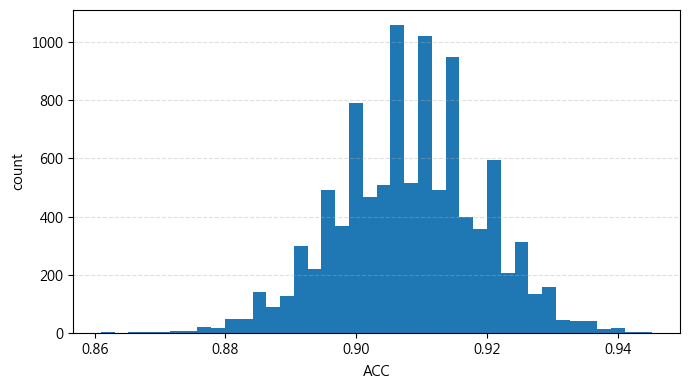

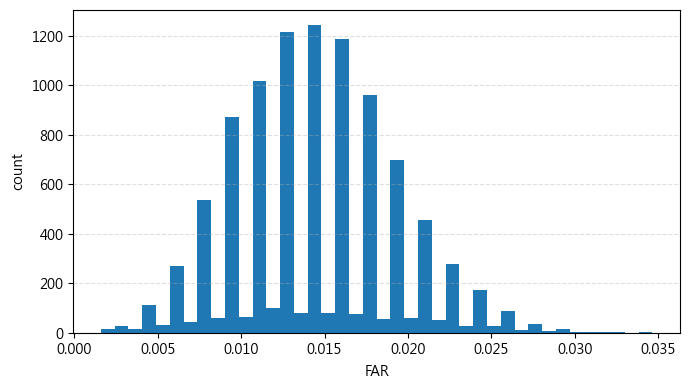

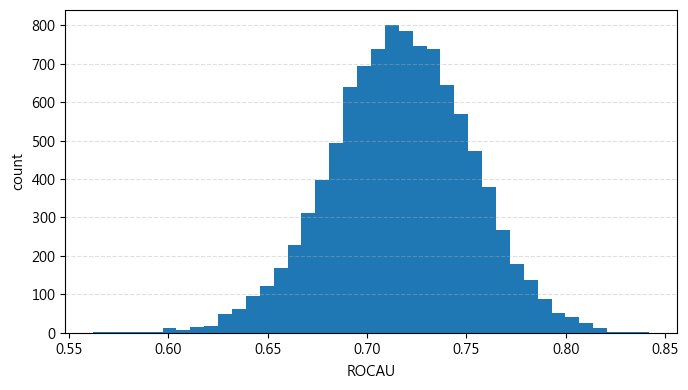


Summary (5-Fold mean):
             acc     FAR   ROCAU
model                          
XGBoost  0.9083  0.0145  0.7157


In [ ]:
mask = (c_all == 0)
X_sub = X_all_df.loc[mask].values
y_sub = y.loc[mask].values.astype(int)

model = {
    'XGBoost': XGBClassifier(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=1,
    gamma=0,
    reg_lambda=1.0,
    reg_alpha=0.0,
    random_state=42,
    n_jobs=-1,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    )
}

# ====== 五摺交叉驗證 ======
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []
for name, clf in model.items():
    fold_metrics = []
    cm_sum = np.zeros((2, 2), dtype=float)

    # ====== 新增：OOF 儲存（每筆樣本只會被填一次）======
    oof_score = np.full(len(y_sub), np.nan, dtype=float)  # OOF proba for positive class
    oof_true  = np.full(len(y_sub), np.nan, dtype=float)  # store y_true for safety
    # ================================================

    print(f"\n=== {name} ===")
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_sub, y_sub), 1):
        Xtr, Xte = X_sub[train_idx], X_sub[test_idx]
        ytr, yte = y_sub[train_idx], y_sub[test_idx]

        smote = SMOTE(random_state=42, sampling_strategy=0.5, k_neighbors=5)
        Xtr_res, ytr_res = smote.fit_resample(Xtr, ytr)

        m = clone(clf)
        m.fit(Xtr_res, ytr_res)

        yhat = predict_labels(m, Xte)
        ys = predict_score(m, Xte)

        # ====== 新增：寫入 OOF ======
        oof_score[test_idx] = ys
        oof_true[test_idx] = yte
        # ==========================

        met = compute_metrics(yte, yhat, ys)
        fold_metrics.append(met)
        cm_sum += met["cm"]
        print(f"Fold {fold}: acc={met['acc']:.3f}, FAR={met['FAR']:.3f}, ROCAU={met['ROCAU']:.3f}")

    avg_metrics = pd.DataFrame(fold_metrics).drop(columns='cm').mean().to_dict()
    avg_metrics['model'] = name
    cv_results.append(avg_metrics)

    cm_mean = cm_sum / skf.get_n_splits()
    print("\nConfusion matrix (mean over 5 folds):")
    print(cm_mean)

    # ====== 新增：OOF bootstrap 95% CI ======
    # 注意：OOF 應該全部被填滿；若有 nan 代表流程有 bug
    valid = ~np.isnan(oof_score)
    ci = bootstrap_ci_from_oof(oof_true[valid], oof_score[valid], thr=0.5, B=10000, alpha=0.05, seed=42)
    print("\nOOF Bootstrap 95% CI (percentile):")
    print(f"ACC  = {ci['ACC'][0]:.4f} [{ci['ACC'][1]:.4f}, {ci['ACC'][2]:.4f}]")
    print(f"FAR  = {ci['FAR'][0]:.4f} [{ci['FAR'][1]:.4f}, {ci['FAR'][2]:.4f}]")
    print(f"ROCAU= {ci['ROCAU'][0]:.4f} [{ci['ROCAU'][1]:.4f}, {ci['ROCAU'][2]:.4f}]")

    # （可選）畫 bootstrap 分佈：三個指標各一張
    boots = ci["boots"]
    for j, lab in enumerate(["ACC", "FAR", "ROCAU"]):
        plt.figure(figsize=(7,4))
        plt.hist(boots[:, j][~np.isnan(boots[:, j])], bins=40)
        plt.xlabel(lab); plt.ylabel("count")
        plt.grid(True, axis="y", linestyle="--", alpha=0.4)
        plt.tight_layout()
        plt.show()
    # =====================================

metrics_df = pd.DataFrame(cv_results).set_index('model').loc[model.keys()]
print("\nSummary (5-Fold mean):\n", metrics_df.round(4))


=== XGBoost ===
Fold 1: acc=0.953, FAR=0.012, ROCAU=0.589
Fold 2: acc=0.953, FAR=0.000, ROCAU=0.553
Fold 3: acc=0.959, FAR=0.000, ROCAU=0.651
Fold 4: acc=0.941, FAR=0.012, ROCAU=0.654
Fold 5: acc=0.935, FAR=0.025, ROCAU=0.686

Confusion matrix (mean over 5 folds):
[[160.6   1.6]
 [  7.2   0.4]]

OOF Bootstrap 95% CI (percentile):
ACC  = 0.9482 [0.9329, 0.9623]
FAR  = 0.0099 [0.0037, 0.0172]
ROCAU= 0.6224 [0.5228, 0.7171]


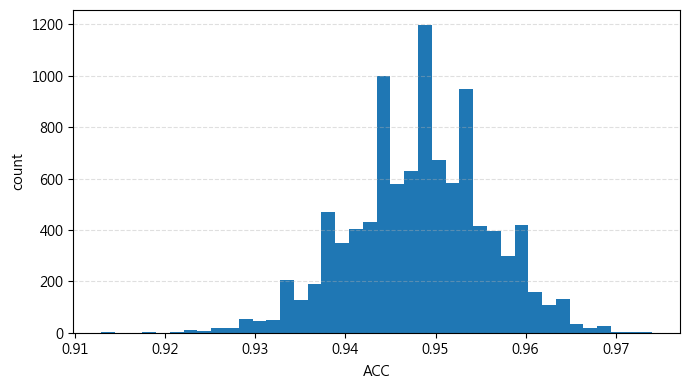

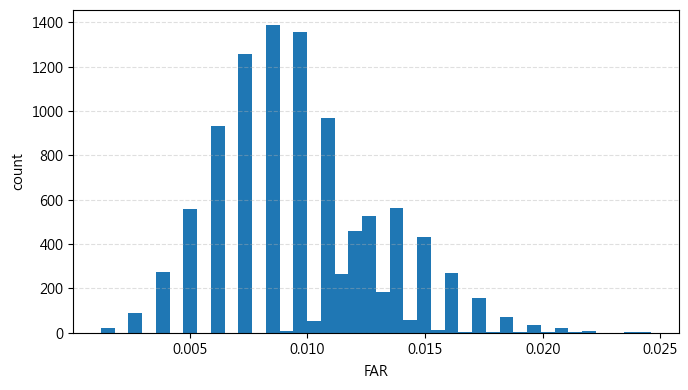

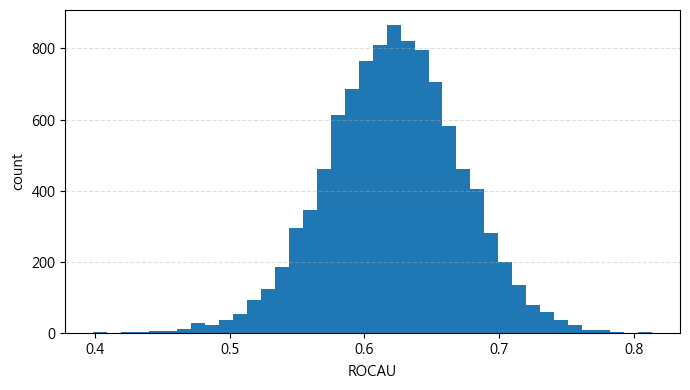


Summary (5-Fold mean):
             acc     FAR   ROCAU
model                          
XGBoost  0.9482  0.0099  0.6266


In [ ]:
mask = (c_all == 1)
X_sub = X_all_df.loc[mask].values
y_sub = y.loc[mask].values.astype(int)

model = {
    'XGBoost': XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=10,
        gamma=1.0,
        reg_lambda=2.0,
        reg_alpha=0.5,
        random_state=42,
        n_jobs=-1,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
    )
}

# ====== 新增：bootstrap CI（用 OOF 預測做抽樣）======
def bootstrap_ci_from_oof(y_true, y_score, thr=0.5, B=10000, alpha=0.05, seed=42):
    """
    y_true: (n,) 0/1
    y_score: (n,) OOF predicted proba for positive class (Fail)
    回傳：point estimate + percentile 95% CI for ACC, FAR, ROCAU
    """
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    n = len(y_true)
    rng = np.random.default_rng(seed)

    def met_on_arrays(yt, ys):
        yp = (ys >= thr).astype(int)
        m = compute_metrics(yt, yp, ys)
        return m['acc'], m['FAR'], m['ROCAU']

    # point
    p_acc, p_far, p_auc = met_on_arrays(y_true, y_score)

    # bootstrap
    boots = np.empty((B, 3), dtype=float)
    for b in range(B):
        idx = rng.integers(0, n, size=n)  # sample with replacement
        boots[b, :] = met_on_arrays(y_true[idx], y_score[idx])

    lo = np.nanquantile(boots, alpha / 2, axis=0)
    hi = np.nanquantile(boots, 1 - alpha / 2, axis=0)

    return {
        "ACC": (p_acc, lo[0], hi[0]),
        "FAR": (p_far, lo[1], hi[1]),
        "ROCAU": (p_auc, lo[2], hi[2]),
        "boots": boots
    }

# ====== 五摺交叉驗證 ======
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []
for name, clf in model.items():
    fold_metrics = []
    cm_sum = np.zeros((2, 2), dtype=float)

    # ====== 新增：OOF 儲存（每筆樣本只會被填一次）======
    oof_score = np.full(len(y_sub), np.nan, dtype=float)  # OOF proba for positive class
    oof_true  = np.full(len(y_sub), np.nan, dtype=float)  # store y_true for safety
    # ================================================

    print(f"\n=== {name} ===")
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_sub, y_sub), 1):
        Xtr, Xte = X_sub[train_idx], X_sub[test_idx]
        ytr, yte = y_sub[train_idx], y_sub[test_idx]

        smote = SMOTE(random_state=42, sampling_strategy=1, k_neighbors=5)
        Xtr_res, ytr_res = smote.fit_resample(Xtr, ytr)

        m = clone(clf)
        m.fit(Xtr_res, ytr_res)

        yhat = predict_labels(m, Xte)
        ys = predict_score(m, Xte)

        # ====== 新增：寫入 OOF ======
        oof_score[test_idx] = ys
        oof_true[test_idx] = yte
        # ==========================

        met = compute_metrics(yte, yhat, ys)
        fold_metrics.append(met)
        cm_sum += met["cm"]
        print(f"Fold {fold}: acc={met['acc']:.3f}, FAR={met['FAR']:.3f}, ROCAU={met['ROCAU']:.3f}")

    avg_metrics = pd.DataFrame(fold_metrics).drop(columns='cm').mean().to_dict()
    avg_metrics['model'] = name
    cv_results.append(avg_metrics)

    cm_mean = cm_sum / skf.get_n_splits()
    print("\nConfusion matrix (mean over 5 folds):")
    print(cm_mean)

    # ====== 新增：OOF bootstrap 95% CI ======
    # 注意：OOF 應該全部被填滿；若有 nan 代表流程有 bug
    valid = ~np.isnan(oof_score)
    ci = bootstrap_ci_from_oof(oof_true[valid], oof_score[valid], thr=0.5, B=10000, alpha=0.05, seed=42)
    print("\nOOF Bootstrap 95% CI (percentile):")
    print(f"ACC  = {ci['ACC'][0]:.4f} [{ci['ACC'][1]:.4f}, {ci['ACC'][2]:.4f}]")
    print(f"FAR  = {ci['FAR'][0]:.4f} [{ci['FAR'][1]:.4f}, {ci['FAR'][2]:.4f}]")
    print(f"ROCAU= {ci['ROCAU'][0]:.4f} [{ci['ROCAU'][1]:.4f}, {ci['ROCAU'][2]:.4f}]")

    # （可選）畫 bootstrap 分佈：三個指標各一張
    boots = ci["boots"]
    for j, lab in enumerate(["ACC", "FAR", "ROCAU"]):
        plt.figure(figsize=(7,4))
        plt.hist(boots[:, j][~np.isnan(boots[:, j])], bins=40)
        plt.xlabel(lab); plt.ylabel("count")
        plt.grid(True, axis="y", linestyle="--", alpha=0.4)
        plt.tight_layout()
        plt.show()
    # =====================================

metrics_df = pd.DataFrame(cv_results).set_index('model').loc[model.keys()]
print("\nSummary (5-Fold mean):\n", metrics_df.round(4))